In [369]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# from collections import Counter  # to find most common words
import seaborn as sns  # at least for heatmap
import re


relativepath = 'C:\\Users\\Veronika\\DATABASES\\EnergyConsumption\\'

In [370]:
print(pd.__version__)
print(sns.__version__)

1.2.4
0.11.1


In [371]:
pd.set_option('display.max_columns', 70)

In [372]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

In [373]:
from sklearn.dummy import DummyRegressor

In [374]:
from time import time
# import datetime

In [375]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, RidgeCV, LassoCV, SGDRegressor, ElasticNet
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline, make_union
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [376]:
import xgboost as xgb
# ModuleNotFoundError: No module named 'xgboost'
# after 'pip install' doesn't rise an error

from xgboost.sklearn import XGBRegressor
# ModuleNotFoundError: No module named 'xgboost'
# after 'pip install' doesn't rise an error

In [377]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Collecting xgboost
  Downloading xgboost-1.4.2-py3-none-win_amd64.whl (97.8 MB)
Requirement already satisfied: numpy in c:\users\veronika\anaconda3\lib\site-packages (from xgboost) (1.20.1)
Requirement already satisfied: scipy in c:\users\veronika\anaconda3\lib\site-packages (from xgboost) (1.6.2)
Installing collected packages: xgboost
Successfully installed xgboost-1.4.2
Note: you may need to restart the kernel to use updated packages.
  WARNING: Retrying (Retry(total=4, connect=None, read=None, redirect=None, status=None)) after connection broken by 'NewConnectionError('<pip._vendor.urllib3.connection.HTTPSConnection object at 0x00000231B346B0D0>: Failed to establish a new connection: [Errno 11001] getaddrinfo failed')': /packages/d4/60/845dd265c7265d3bd44906d1c15be2908ff0655b32d9000935aeaeef6677/xgboost-1.4.2-py3-none-win_amd64.whl

In [378]:
raw_data = pd.read_csv(relativepath + 'seattle_energy_predict.csv')

In [379]:
data_with_score = raw_data[raw_data.ENERGYSTARScore.notnull()]

In [380]:
data_train, data_test = train_test_split(data_with_score, test_size=0.25, random_state = 1)

# CO2 Emissions

In [381]:
optimal_params = []

In [382]:
errors = []

In [383]:
log_errors = []

## With ENERGYSTARScore (no ENERGYSTARScoreTimesGFA)

In [384]:
target_columns = ['TotalGHGEmissions']
drop_columns = ['TotalGHGEmissions', 'LogGHGEmissions',
               'TotalGHGEmissions', 'LogGHGEmissions',
               'OSEBuildingID', 'ScoreTimesGFA']

y_train = data_train[target_columns]
y_test = data_test[target_columns]

X_train = data_train.drop(drop_columns, axis=1)
X_test = data_test.drop(drop_columns, axis=1)

y = data_with_score[target_columns]
X = data_with_score.drop(drop_columns, axis=1)

In [385]:
preprocessor1 = make_column_transformer(
    (StandardScaler(),
     X.select_dtypes(include=['int64','float64']).columns),
    (OneHotEncoder
     (categories = [data_with_score[feature].unique() for feature in X.select_dtypes(exclude=['int64','float64']).columns],
      drop='first'),
     X.select_dtypes(exclude=['int64','float64']).columns))
# if error raises, remove drop='first' from OnehotEncoder

### Baseline: dummy regressors

For dummy regressors, preprocessor isn't necessary, because target y is independent from features X.

In [386]:
model = DummyRegressor(strategy='mean')

start = time()
model.fit(X_train, y_train['TotalGHGEmissions'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

# to get a train score, I will form an array, length of X train, having all values equal mean of X train
y_pred_train = model.predict(X_train)

errors.append(['dummy_mean', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

errors.append(['dummy_mean', 'from_train', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

### Basic regression, not regularized

In [387]:
model = make_pipeline(preprocessor1,LinearRegression())

start = time()
model.fit(X_train, y_train['TotalGHGEmissions'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

print('Root mean squared error:',  round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)),
print('Mean absolute error:',  round(mean_absolute_error(y_test, y_pred), 3)),
print('Model score on test set:',  model.score(X_test, y_test)),
print('Model score on training set:',model.score(X_train, y_train))
print('Fit time:', fit_time - start)

Root mean squared error: 94.74
Mean absolute error: 59.939
Model score on test set: 0.4880518121153936
Model score on training set: 0.7750909788453535
Fit time: 0.023935317993164062


### Basic linear regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [388]:
pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=LinearRegression(), 
                          param_grid={}, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

In [389]:
y_pred = model.predict(X_test)

In [390]:
errors.append(['LR_simple', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),  # model.score(X_test, y_test) - it's a MAE now, because I set it in refit,
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [391]:
errors.append(['LR_simple', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Ridge regression illustration: manual choice of alpha

Please note: here the test set is used for the choice of hyperparameter, but it's because this section is only for demonstration of principle and illustration. The resulting model hasn't entered in the results comparison.

The Ridge Model for for models performance comparison selected alpha parameter only on train set.

In [392]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [393]:
n_alphas = 50
alphas = np.logspace(-1, 4, n_alphas)

ridge = Ridge()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Ridge = []
errors_Ridge = []
for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X1, y_train['TotalGHGEmissions'])
    coefs_Ridge.append(ridge.coef_)
#     errors_Ridge.append(np.mean((ridge.predict(X2) - y_test['TotalGHGEmissions']) ** 2).values[0])
    errors_Ridge.append(np.sqrt(np.mean((ridge.predict(X2) - y_test['TotalGHGEmissions']) ** 2)))
#     it's the way to calculate mean squared error

Sometimes we see that the curve (Ridge error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Ridge Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

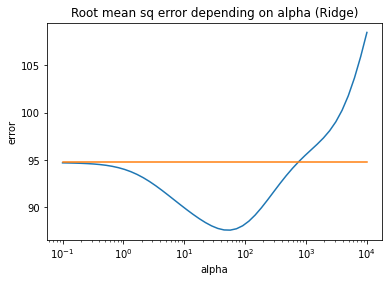

In [394]:
ax = plt.gca()

ax.plot(alphas, errors_Ridge)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Ridge)')
plt.show()

In [395]:
print('the minimal errors_Ridge is', min(errors_Ridge), 'in position', errors_Ridge.index(min(errors_Ridge)))
print('alpha parameter for the minimal error is', alphas[errors_Ridge.index(min(errors_Ridge))])

the minimal errors_Ridge is 87.6064186378398 in position 27
alpha parameter for the minimal error is 56.89866029018299


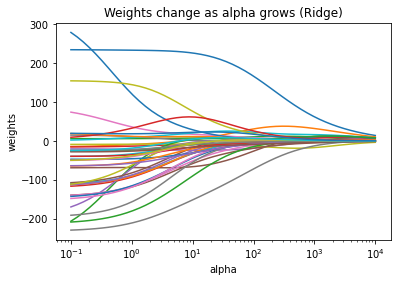

In [396]:
ax = plt.gca()

ax.plot(alphas, coefs_Ridge)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Ridge)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the ridge calculation below

### Lasso regression illustration: manual choice of alpha

In [397]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [398]:
n_alphas = 50
alphas = np.logspace(-3, 3, n_alphas)

lasso = Lasso(max_iter=10_000)
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Lasso = []
errors_Lasso = []
for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X1, y_train['TotalGHGEmissions'])
    coefs_Lasso.append(lasso.coef_)
#     errors_Lasso.append(np.mean((lasso.predict(X2) - y_test['TotalGHGEmissions']) ** 2).values[0])
    errors_Lasso.append(np.sqrt(np.mean((lasso.predict(X2) - y_test['TotalGHGEmissions']) ** 2)))
#     it's the way to calculate mean squared error

Sometimes we see that the curve (Lasso error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Lasso Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

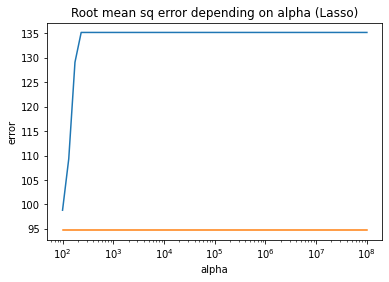

In [399]:
ax = plt.gca()

ax.plot(alphas, errors_Lasso)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Lasso)')
plt.show()

In [400]:
print('the minimal errors_Lasso is', min(errors_Lasso), 'in position', errors_Lasso.index(min(errors_Lasso)))
print('alpha parameter for the minimal error is', alphas[errors_Lasso.index(min(errors_Lasso))])

the minimal errors_Lasso is 98.81710964940447 in position 0
alpha parameter for the minimal error is 100.0


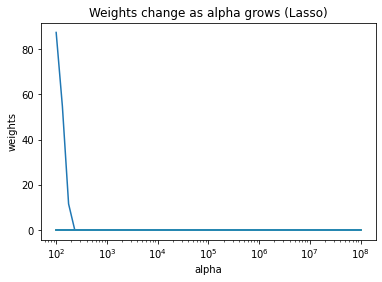

In [401]:
ax = plt.gca()

ax.plot(alphas, coefs_Lasso)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Lasso)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the lasso calculation below

### Ridge regression with cross-validation

There is an implemented function for cross-validation in Ridge regression, called RidgeCV.

This implementation doesn't allow use multiple scores:

ValueError: For multi-metric scoring, the parameter refit must be set to a scorer key or a callable to refit an estimator with the best parameter setting on the whole data and make the best_* attributes available for that metric. If this is not needed, refit should be set to False explicitly. True was passed.

When I add the refit parameter, another error raises:

TypeError: __init__() got an unexpected keyword argument 'refit'

So for my purposes of multiple metrics, I will use standart Ridge with GridSearch

In [402]:
param_test = {'alpha': np.logspace(-1, 3, 10)}

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Ridge(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_ridge.py:555: UserWarning: "sag" solver requires many iterations to fit an intercept with sparse inputs. Either set the solver to "auto" or "sparse_cg", or set a low "tol" and a high "max_iter" (especially if inputs are not standardized).

'sag' solver was removed from the parameters grid.

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: 

I have just kept only 'auto' solver.

In [403]:
# tygdyk
model[1].best_params_

{'alpha': 0.774263682681127}

In [404]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Ridge'
optimal_params.append(['Ridge', param_stock])

In [405]:
y_pred = model.predict(X_test)

errors.append(['Ridge', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [406]:
errors.append(['Ridge', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Lasso regression with cross-validation

There is an implemented function for cross-validation in Lasso regression, called LassoCV.

This implementation doesn't allow using multiple scores, and, unlike RidgeCV above, it doesn't allow to choose the score. It minimizes the optimization function (mean_squared error + alpha * |L1|.

In [407]:
param_test = {'alpha': np.logspace(-3, 5, 9),
#               'precompute': [False, True],  # default parameter False is better for all the test I did
             'selection': ['random', 'cyclic']}


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Lasso(tol=1, max_iter = 1000_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error'))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

In [408]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'selection': 'cyclic'}

The alpha parameter is different with every click!

When I launch the Lasso model several times in circle, I observe whatever alpha parameters from 0.0001 to 100000!
Maybe it depends on data splits during cross-validation, because all the parameters stay intact.

Maybe the varied results are due to high tolerance? But when I tried to use the standard value 10**-4 for tolerance, even 1000000 iterations is not enough! The warning rises that the function did not converge.

In [409]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Lasso'
optimal_params.append(['Lasso', param_stock])

In [410]:
y_pred = model.predict(X_test)

errors.append(['Lasso', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [411]:
errors.append(['Lasso', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Elastic Net regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [412]:
param_test = {'alpha': np.logspace(-3, 3, 7),
             'l1_ratio': np.linspace(0.1, 0.9, 9),
#              'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=ElasticNet(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

for each of RMSE, MAE and R2 score

In [413]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'l1_ratio': 0.6}

In [414]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Elastic Net'
optimal_params.append(['Elastic Net', param_stock])

In [415]:
y_pred = model.predict(X_test)

errors.append(['ElasticNet', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [416]:
errors.append(['ElasticNet', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Random Forest Regressor with cross-validation

In [417]:
param_test = {'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
#              'criterion': ['mse', 'mae'],  # default value is mse
#              'max_depth': [4, 6, 9, None], # default value None is the best for most part of the tests
#              'min_samples_split': [2, 5, 20],  # default value 2 is the best
#              'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#              'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#              'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#              'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
             'min_impurity_decrease': [0, 0.1, 1],  # best param varies from one click to another
#              'verbose': [0],
#              'ccp_alpha': [0],  # should be non-negative
#              'max_samples': [None, 900]  #if take less than None, model doesn't converge
             }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=RandomForestRegressor(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:880: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

In [418]:
# tygdyk
model[1].best_params_

{'min_impurity_decrease': 0.1, 'n_estimators': 100}

In [419]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [420]:
y_pred = model.predict(X_test)

errors.append(['Random_Forest', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [421]:
errors.append(['Random_Forest', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Gradient Boosting Regressor with cross-validation

In [422]:
param_test = {'loss': ['ls', 'lad', 'huber', 'quantile'], # huber is the best
#               'learning_rate': [0.2, 0.1, 0.05], # default value 0.1 is best of 0.2, 0.1, 0.05
              'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
              'max_depth': [4, 6, 9, None], # default value None is the best, sometimes 4
#               'subsample': [1.0, 0.9],
#               'min_samples_split': [2, 5, 10],  # default value 2 is the best
#               'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#               'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#               'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#               'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
              'min_impurity_decrease': [1, 10, 100],  # best param varies from one click to another
              }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=GradientBoostingRegressor(n_iter_no_change=5, tol = 0.1), 
                          param_grid=param_test, 
                          cv=3, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

In [423]:
# tygdyk
model[1].best_params_

{'loss': 'huber',
 'max_depth': 9,
 'min_impurity_decrease': 1,
 'n_estimators': 200}

In [424]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [425]:
y_pred = model.predict(X_test)

errors.append(['Gradient_Boosting', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [426]:
errors.append(['Gradient_Boosting', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

###  XGB Regressor with cross-validation, Learning API

In [427]:
prepr_fitted = preprocessor1.fit(X_train)
X1 = prepr_fitted.transform(X_train)
X2 = prepr_fitted.transform(X_test)

dtrain = xgb.DMatrix(X1, label=y_train['TotalGHGEmissions'])
dtest = xgb.DMatrix(X2, label=y_test['TotalGHGEmissions'])

In [428]:
# guide for parameters tuning: https://blog.cambridgespark.com/hyperparameter-tuning-in-xgboost-4ff9100a3b2f
# notice the importance of the seed

params = {
    # Parameters that we are going to tune.
    'max_depth':6,
    'min_child_weight': 1,
    'eta':.3,
    'subsample': 1,
    'colsample_bytree': 1,
    # Other parameters
    'objective':'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}
num_boost_round = 999

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/objective/regression_obj.cu:171: reg:linear is now deprecated in favor of reg:squarederror.

In [429]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:125.63671	Test-mae:71.60562
[1]	Test-rmse:103.64998	Test-mae:55.54819
[2]	Test-rmse:90.85645	Test-mae:47.54214
[3]	Test-rmse:79.74857	Test-mae:43.72773
[4]	Test-rmse:75.83831	Test-mae:42.89791
[5]	Test-rmse:71.43733	Test-mae:41.53663
[6]	Test-rmse:71.04097	Test-mae:41.55022
[7]	Test-rmse:69.08179	Test-mae:40.82789
[8]	Test-rmse:69.70499	Test-mae:41.15144
[9]	Test-rmse:70.06674	Test-mae:41.63142
[10]	Test-rmse:69.45280	Test-mae:41.28588
[11]	Test-rmse:68.62090	Test-mae:41.10768
[12]	Test-rmse:68.57196	Test-mae:41.01740
[13]	Test-rmse:68.84536	Test-mae:40.66012
[14]	Test-rmse:69.32384	Test-mae:41.03931
[15]	Test-rmse:69.60278	Test-mae:40.92740
[16]	Test-rmse:69.20216	Test-mae:40.53332
[17]	Test-rmse:69.02057	Test-mae:40.27549
[18]	Test-rmse:68.94031	Test-mae:40.12814
[19]	Test-rmse:68.51484	Test-mae:40.07777
[20]	Test-rmse:68.11204	Test-mae:39.52534
[21]	Test-rmse:67.21738	Test-mae:39.15923
[22]	Test-rmse:67.94085	Test-mae:39.38627
[23]	Test-rmse:67.49094	Test-mae:38.89902


In [430]:
print("Best MAE: {:.2f} with {} rounds".format(
                 model.best_score,
                 model.best_iteration+1))

Best MAE: 36.28 with 74 rounds


In [431]:
cv_results = xgb.cv(params, 
                    dtrain, 
                    num_boost_round=num_boost_round, 
                    seed=42, 
                    nfold=5, 
                    metrics={'rmse', 'mae'},  # 'r2' or 'r2score' doesn't exist
                    early_stopping_rounds=10)

In [432]:
cv_results['test-mae-mean'].min()

48.874331

In [433]:
gridsearch_params = [
    (max_depth, min_child_weight)
    for max_depth in (2,3,6)
    for min_child_weight in np.logspace(-8, 0, 3) #in range(5,8)
]

In [434]:
# Define initial best params and MAE
min_mae = float("Inf")
min_rmse = float("Inf")
# best_params = None

for max_depth, min_child_weight in gridsearch_params:
#     print("CV with max_depth={}, min_child_weight={}".format(
#                              max_depth,
#                              min_child_weight))
    # Update our parameters
    params['max_depth'] = max_depth
    params['min_child_weight'] = min_child_weight
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best MAE
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (max_depth,min_child_weight)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: max depth {}, min child weight{}, MAE: {}, RMSE: {}".format(best_params[0], 
                                                                                best_params[1], min_mae, min_rmse))

params['max_depth'] = best_params[0]
params['min_child_weight'] = best_params[1]

Best params: max depth 6, min child weight1e-08, MAE: 48.874331, RMSE: 106.7704332


In [435]:
gridsearch_params = [
    (subsample, colsample)
    for subsample in [i/10. for i in range(6,11,2)]
    for colsample in [i/10. for i in range(6,11,2)]
]

In [436]:
min_mae = float("Inf")
min_rmse = float("Inf")
best_params = None

# Start by the largest values and go down to the smallest
for subsample, colsample in reversed(gridsearch_params):
#     print("CV with subsample={}, colsample={}".format(
#                              subsample,
#                              colsample))

    # Update parameters
    params['subsample'] = subsample
    params['colsample_bytree'] = colsample
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (subsample,colsample)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

params['subsample'] = best_params[0]
params['colsample_bytree'] = best_params[1]

Best params: 1.0, 0.8, MAE: 48.5820694


In [437]:
%time
min_mae = float("Inf")
best_params = None
for eta in [.3, .2, .1, .05, .01, .005]:
#     print("CV with eta={}".format(eta))
    
    # Update parameters
    params['eta'] = eta
    # Run and time CV
    %time cv_results = xgb.cv(params,dtrain,num_boost_round=num_boost_round,seed=42,nfold=5,metrics=['rmse','mae'],early_stopping_rounds=10)
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds\n".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = eta
    if mean_mae < min_mae:
        min_mae = mean_mae
print("Best params: {}, MAE: {}, RMSE: {}".format(best_params, min_mae, min_rmse))

params['eta'] = best_params

Wall time: 0 ns
Wall time: 404 ms
Wall time: 570 ms
Wall time: 1.16 s
Wall time: 2.2 s
Wall time: 6.72 s
Wall time: 6.54 s
Best params: 0.2, MAE: 46.5809272, RMSE: 107.9657148


In [438]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:139.75740	Test-mae:82.29157
[1]	Test-rmse:122.02450	Test-mae:68.72832
[2]	Test-rmse:108.13469	Test-mae:59.00290
[3]	Test-rmse:96.53637	Test-mae:52.64573
[4]	Test-rmse:89.27845	Test-mae:48.86138
[5]	Test-rmse:83.03130	Test-mae:46.20016
[6]	Test-rmse:81.73113	Test-mae:45.41149
[7]	Test-rmse:77.41791	Test-mae:43.88582
[8]	Test-rmse:75.72229	Test-mae:42.67444
[9]	Test-rmse:72.95408	Test-mae:41.22125
[10]	Test-rmse:69.63676	Test-mae:40.05541
[11]	Test-rmse:68.70922	Test-mae:39.73774
[12]	Test-rmse:66.85826	Test-mae:39.42743
[13]	Test-rmse:65.72765	Test-mae:39.16559
[14]	Test-rmse:65.21867	Test-mae:38.77452
[15]	Test-rmse:64.80030	Test-mae:38.46822
[16]	Test-rmse:64.72060	Test-mae:38.21487
[17]	Test-rmse:64.65429	Test-mae:38.13713
[18]	Test-rmse:64.75351	Test-mae:38.29777
[19]	Test-rmse:64.39562	Test-mae:38.16764
[20]	Test-rmse:64.54466	Test-mae:38.26722
[21]	Test-rmse:63.62710	Test-mae:38.13951
[22]	Test-rmse:63.42593	Test-mae:37.97040
[23]	Test-rmse:63.33455	Test-mae:37.86357

In [439]:
print("Best MAE: {:.2f} in {} rounds".format(model.best_score, model.best_iteration+1))

Best MAE: 34.63 in 60 rounds


In [440]:
num_boost_round = model.best_iteration + 1
best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")])

[0]	Test-rmse:139.75740	Test-mae:82.29157
[1]	Test-rmse:122.02450	Test-mae:68.72832
[2]	Test-rmse:108.13469	Test-mae:59.00290
[3]	Test-rmse:96.53637	Test-mae:52.64573
[4]	Test-rmse:89.27845	Test-mae:48.86138
[5]	Test-rmse:83.03130	Test-mae:46.20016
[6]	Test-rmse:81.73113	Test-mae:45.41149
[7]	Test-rmse:77.41791	Test-mae:43.88582
[8]	Test-rmse:75.72229	Test-mae:42.67444
[9]	Test-rmse:72.95408	Test-mae:41.22125
[10]	Test-rmse:69.63676	Test-mae:40.05541
[11]	Test-rmse:68.70922	Test-mae:39.73774
[12]	Test-rmse:66.85826	Test-mae:39.42743
[13]	Test-rmse:65.72765	Test-mae:39.16559
[14]	Test-rmse:65.21867	Test-mae:38.77452
[15]	Test-rmse:64.80030	Test-mae:38.46822
[16]	Test-rmse:64.72060	Test-mae:38.21487
[17]	Test-rmse:64.65429	Test-mae:38.13713
[18]	Test-rmse:64.75351	Test-mae:38.29777
[19]	Test-rmse:64.39562	Test-mae:38.16764
[20]	Test-rmse:64.54466	Test-mae:38.26722
[21]	Test-rmse:63.62710	Test-mae:38.13951
[22]	Test-rmse:63.42593	Test-mae:37.97040
[23]	Test-rmse:63.33455	Test-mae:37.86357

In [441]:
y_pred = best_model.predict(dtest)
mean_absolute_error(y_pred, y_test)
np.sqrt(mean_squared_error(y_test, y_pred))

60.16673865618962

In [442]:
y_pred = best_model.predict(dtest)

errors.append(['XGB_LearningAPI', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               9.999])
# 

As XGBoost doesn't have R2 score in metrics in cross-validation, I calculate a train r2 score without cross-validation. 
Minimal RMSE and MAE can be found from cv_results dataframe, but the model has been updated since that: not only the parameters are optimized, but the number of iterations as well.

In [443]:
y_train_pred = best_model.predict(dtrain)

errors.append(['XGB_LearningAPI', 'from_train', 'with_score',
               round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 3),
               round(mean_absolute_error(y_train, y_train_pred), 3),
               round(r2_score(y_train, y_train_pred), 3),
#                model.score(X_train, y_train),
               9.999])
# 

'num_boost_round': 200 in params raises an error:

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "num_boost_round" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.

###  XGB Regressor with cross-validation, SKLearn API (wrapper)

In [444]:
y_train['TotalGHGEmissions'].mean()

130.3424976167778

In [445]:
# full list of params https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn
# parameters: general ones, and divided by subcategory: https://xgboost.readthedocs.io/en/latest/parameter.html

param_test = {
           'n_estimators': [100, 200, 300], # from 100,200,500 best is 200
           'max_depth': [3, 6, 10], # by default 6, and 6 have been shown the best
#            'learning_rate': [0.3, 0.1, 0.05], # by default 0.3. tried 0.01 - it's better but much slower
#            'colsample_bytree': [0.3, 0.7], 
           'alpha': [0, 0.001, 0.01, 0.1],# by default 0, best shown 0.001, sometimes 0.01 with the same random state
           'lambda': [0, 1, 3, 5]  # default is 1, best shown 3 from 0.1,1,3
            }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=XGBRegressor(objective='reg:squarederror', base_score=y_train['TotalGHGEmissions'].median()), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

In [446]:
# tygdyk
model[1].best_params_

{'alpha': 0.1, 'lambda': 5, 'max_depth': 3, 'n_estimators': 200}

In [447]:
param_stock = model[1].best_params_
# param_stock['name'] = 'XGBRegressor'
optimal_params.append(['XGBRegressor', param_stock])

In [448]:
# model[1].cv_results_ extremely long dictionary

In [449]:
y_pred = model.predict(X_test)

errors.append(['XGBRegressor', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [450]:
errors.append(['XGBRegressor', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### SGD Regressor with cross-validation (Stochastic Gradient Descent)

The gradient of the loss is estimated each sample at a time and the model is updated along the way with a decreasing strength schedule (aka learning rate).

The regularizer is a penalty added to the loss function that shrinks model parameters towards the zero vector using either the squared euclidean norm L2 or the absolute norm L1 or a combination of both (Elastic Net). If the parameter update crosses the 0.0 value because of the regularizer, the update is truncated to 0.0 to allow for learning sparse models and achieve online feature selection.

This implementation works with data represented as dense numpy arrays of floating point values for the features.

In [451]:
param_test = {
    'loss': ['squared_loss', 'huber'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': np.logspace(-3, 3, 7),
    'l1_ratio': np.linspace(0.1, 0.9, 9),
    'learning_rate': ['constant', 'invscaling', 'adaptive'], # default invscaling
    }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SGDRegressor(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

In [452]:
# tygdyk
model[1].best_params_

{'alpha': 0.001,
 'l1_ratio': 0.9,
 'learning_rate': 'invscaling',
 'loss': 'squared_loss',
 'penalty': 'elasticnet'}

In [453]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SGDegressor'
optimal_params.append(['SGDegressor', param_stock])

In [454]:
y_pred = model.predict(X_test)

errors.append(['SGDRegressor', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [455]:
errors.append(['SGDRegressor', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### SV Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [456]:
param_test = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
#     kernel 'precomputed' raises an error: the precomputed kernel matrix must be used
    'C': [1, 10, 100], # default is 1, best is 5 from 0.2, 1, 5
    'epsilon': [0.1, 1, 10]
     }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SVR(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\svm\_base.py:255: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn('Solver terminated early (max_iter=%i).'


C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

In [457]:
# tygdyk
model[1].best_params_

{'C': 100, 'epsilon': 10, 'kernel': 'linear'}

In [458]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SVR'
optimal_params.append(['SVR', param_stock])

In [459]:
y_pred = model.predict(X_test)

errors.append(['SVR', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [460]:
errors.append(['SVR', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

## Set the logarithm of CO2 EMissions as target column

In [461]:
target_columns = ['LogGHGEmissions']
drop_columns = ['TotalGHGEmissions', 'LogGHGEmissions',
               'TotalGHGEmissions', 'LogGHGEmissions',
               'OSEBuildingID', 'ScoreTimesGFA']

y_train = data_train[target_columns]
y_train_exp = data_train['TotalGHGEmissions']
y_test = data_test[target_columns]
y_test_exp = data_test['TotalGHGEmissions']

X_train = data_train.drop(drop_columns, axis=1)
X_test = data_test.drop(drop_columns, axis=1)

y = data_with_score[target_columns]
X = data_with_score.drop(drop_columns, axis=1)

### Baseline: dummy regressors

For dummy regressors, preprocessor isn't necessary, because target y is independent from features X.

R2 (coefficient of determination) regression score function.

Best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of y, disregarding the input features, would get a R2 score of 0.0.

In [462]:
model = DummyRegressor(strategy='mean')

start = time()
model.fit(X_train, y_train['LogGHGEmissions'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

# to get a train score, I will form an array, length of X train, having all values equal median of X train
y_pred_train = model.predict(X_train)

log_errors.append(['dummy_mean', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

log_errors.append(['dummy_mean', 'from_train', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

errors.append(['dummy_mean', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Basic regression, not regularized

In [463]:
model = make_pipeline(preprocessor1,LinearRegression())

start = time()
model.fit(X_train, y_train['LogGHGEmissions'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

print('Root mean squared error:',  round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)),
print('Mean absolute error:',  round(mean_absolute_error(y_test, y_pred), 3)),
print('Model score on test set:',  model.score(X_test, y_test)),
print('Model score on training set:',model.score(X_train, y_train))
print('Fit time:', fit_time - start)

Root mean squared error: 0.528
Mean absolute error: 0.427
Model score on test set: 0.819147166698289
Model score on training set: 0.8621983768863974
Fit time: 0.014275550842285156


### Basic linear regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [464]:
pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=LinearRegression(), 
                          param_grid={}, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

In [465]:
log_errors.append(['LR_simple', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),  # model.score(X_test, y_test) - it's a MAE now, because I set it in refit,
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [466]:
log_errors.append(['LR_simple', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [467]:
errors.append(['LR_simple', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Ridge regression illustration: manual choice of alpha

In [468]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [469]:
n_alphas = 50
alphas = np.logspace(-1, 4, n_alphas)

ridge = Ridge()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Ridge = []
log_errors_Ridge = []
for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X1, y_train['LogGHGEmissions'])
    coefs_Ridge.append(ridge.coef_)
#     log_errors_Ridge.append(np.mean((ridge.predict(X2) - y_test['LogGHGEmissions']) ** 2).values[0])
    log_errors_Ridge.append(np.sqrt(np.mean((ridge.predict(X1) - y_train['LogGHGEmissions']) ** 2)))
#     it's the way to calculate mean squared error

Sometimes we see that the curve (Ridge error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Ridge Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

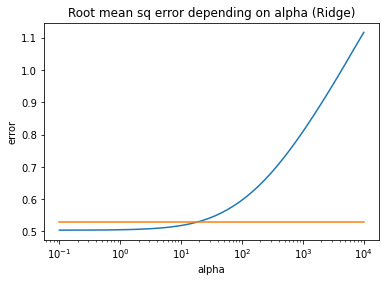

In [470]:
ax = plt.gca()

ax.plot(alphas, log_errors_Ridge)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Ridge)')
plt.show()

In [471]:
print('the minimal log_errors_Ridge is', min(log_errors_Ridge), 'in position', log_errors_Ridge.index(min(log_errors_Ridge)))
print('alpha parameter for the minimal error is', alphas[log_errors_Ridge.index(min(log_errors_Ridge))])

the minimal log_errors_Ridge is 0.5041330307781181 in position 0
alpha parameter for the minimal error is 0.1


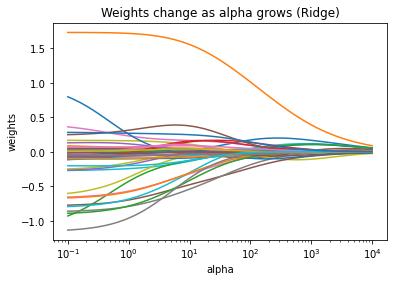

In [472]:
ax = plt.gca()

ax.plot(alphas, coefs_Ridge)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Ridge)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the ridge calculation below

### Lasso regression illustration: manual choice of alpha

In [473]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [474]:
n_alphas = 50
alphas = np.logspace(-5, 1, n_alphas)

lasso = Lasso()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Lasso = []
log_errors_Lasso = []
for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X1, y_train['LogGHGEmissions'])
    coefs_Lasso.append(lasso.coef_)
#     log_errors_Lasso.append(np.mean((lasso.predict(X2) - y_test['LogGHGEmissions']) ** 2).values[0])
    log_errors_Lasso.append(np.sqrt(np.mean((lasso.predict(X2) - y_test['LogGHGEmissions']) ** 2)))
#     it's the way to calculate mean squared error

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 126.25085308115985, tolerance: 0.1934366581871928
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 123.98259026669452, tolerance: 0.1934366581871928
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 121.01526028910382, tolerance: 0.1934366581871928
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530:

Sometimes we see that the curve (Lasso error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Lasso Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

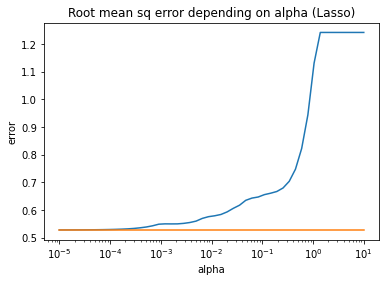

In [475]:
ax = plt.gca()

ax.plot(alphas, log_errors_Lasso)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Lasso)')
plt.show()

In [476]:
print('the minimal log_errors_Lasso is', min(log_errors_Lasso), 'in position', log_errors_Lasso.index(min(log_errors_Lasso)))
print('alpha parameter for the minimal error is', alphas[log_errors_Lasso.index(min(log_errors_Lasso))])

the minimal log_errors_Lasso is 0.5284319923946639 in position 0
alpha parameter for the minimal error is 1e-05


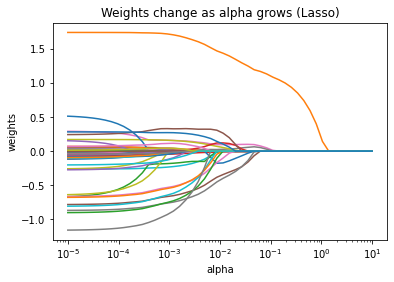

In [477]:
ax = plt.gca()

ax.plot(alphas, coefs_Lasso)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Lasso)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the lasso calculation below

### Ridge regression with cross-validation

In [478]:
param_test = {'alpha': np.logspace(-2, 1, 10)}

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Ridge(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_ridge.py:555: UserWarning: "sag" solver requires many iterations to fit an intercept with sparse inputs. Either set the solver to "auto" or "sparse_cg", or set a low "tol" and a high "max_iter" (especially if inputs are not standardized).

'sag' solver was removed from the parameters grid.

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: 

I have just kept only 'auto' solver.

In [479]:
# tygdyk
model[1].best_params_

{'alpha': 1.0}

In [480]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Ridge'
optimal_params.append(['Ridge', param_stock])

In [481]:
y_pred = model.predict(X_test)

log_errors.append(['Ridge', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [482]:
log_errors.append(['Ridge', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [483]:
errors.append(['Ridge', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Lasso regression with cross-validation

In [484]:
param_test = {'alpha': np.logspace(-4, 2, 7),
             'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Lasso(tol=0.001, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

In [485]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'selection': 'random'}

In [486]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Lasso'
optimal_params.append(['Lasso', param_stock])

In [487]:
y_pred = model.predict(X_test)

log_errors.append(['Lasso', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [488]:
log_errors.append(['Lasso', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [489]:
errors.append(['Lasso', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Elastic Net regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [490]:
param_test = {'alpha': np.logspace(-3, 3, 7),
             'l1_ratio': np.linspace(0.1, 0.9, 9),
#              'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=ElasticNet(max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

for each of RMSE, MAE and R2 score

In [491]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'l1_ratio': 0.9}

In [492]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Elastic Net'
optimal_params.append(['Elastic Net', param_stock])

In [493]:
y_pred = model.predict(X_test)

log_errors.append(['ElasticNet', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [494]:
log_errors.append(['ElasticNet', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [495]:
errors.append(['ElasticNet', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Random Forest Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [496]:
param_test = {'n_estimators': [50, 100, 200, 400], # of 50,100,200,400 best value is 200
#              'criterion': ['mse', 'mae'],  # default value is mse
             'max_depth': [4, 6, 9, None], 
#              'min_samples_split': [2, 4],  # default value 2 is the best
#              'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#              'min_weight_fraction_leaffloat': [0], 
#              'max_features': ['auto', 'sqrt', 'log'], # default value 'auto' is the best, = n_features
#              'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
#              'min_impurity_decrease'[0], 
#              'verbose': [0],
#              'ccp_alpha': [0],  # should be non-negative
#              'max_samples': [None]  #if None, draw X.shape[0] samples
             }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=RandomForestRegressor(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:880: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

In [497]:
# tygdyk
model[1].best_params_

{'max_depth': None, 'n_estimators': 400}

In [498]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [499]:
y_pred = model.predict(X_test)

log_errors.append(['Random_Forest', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [500]:
log_errors.append(['Random_Forest', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [501]:
errors.append(['Random_Forest', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Gradient Boosting Regressor with cross-validation

In [502]:
param_test = {'loss': ['ls', 'lad', 'huber', 'quantile'], # huber is the best
#               'learning_rate': [0.2, 0.1, 0.05], # default value 0.1 is best of 0.2, 0.1, 0.05
              'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
              'max_depth': [4, 6, 9, None], # default value None is the best, sometimes 4
#               'subsample': [1.0, 0.9],
#               'min_samples_split': [2, 5, 10],  # default value 2 is the best
#               'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#               'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#               'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#               'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
              'min_impurity_decrease': [0.001, 0.01, 0.1, 1],  # best param varies from one click to another
              }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=GradientBoostingRegressor(n_iter_no_change=5, tol = 0.1), 
                          param_grid=param_test, 
                          cv=3, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

In [503]:
# tygdyk
model[1].best_params_

{'loss': 'ls', 'max_depth': 4, 'min_impurity_decrease': 1, 'n_estimators': 100}

In [504]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Gradient Boosting Regressor', param_stock])

In [505]:
y_pred = model.predict(X_test)

log_errors.append(['Gradient_Boosting', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [506]:
log_errors.append(['Gradient_Boosting', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [507]:
errors.append(['Gradient_Boosting', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

###  XGB Regressor with cross-validation, Learning API

In [508]:
prepr_fitted = preprocessor1.fit(X_train)
X1 = prepr_fitted.transform(X_train)
X2 = prepr_fitted.transform(X_test)

dtrain = xgb.DMatrix(X1, label=y_train['LogGHGEmissions'])
dtest = xgb.DMatrix(X2, label=y_test['LogGHGEmissions'])

In [509]:
# guide for parameters tuning: https://blog.cambridgespark.com/hyperparameter-tuning-in-xgboost-4ff9100a3b2f
# notice the importance of the seed

params = {
    # Parameters that we are going to tune.
    'max_depth':6,
    'min_child_weight': 1,
    'eta':.3,
    'subsample': 1,
    'colsample_bytree': 1,
    # Other parameters
    'objective':'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}
num_boost_round = 999

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/objective/regression_obj.cu:171: reg:linear is now deprecated in favor of reg:squarederror.

In [510]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:2.60713	Test-mae:2.42138
[1]	Test-rmse:1.88240	Test-mae:1.70746
[2]	Test-rmse:1.40113	Test-mae:1.22383
[3]	Test-rmse:1.07955	Test-mae:0.91578
[4]	Test-rmse:0.87204	Test-mae:0.72274
[5]	Test-rmse:0.73381	Test-mae:0.60122
[6]	Test-rmse:0.64821	Test-mae:0.53585
[7]	Test-rmse:0.59882	Test-mae:0.49040
[8]	Test-rmse:0.57567	Test-mae:0.47017
[9]	Test-rmse:0.55889	Test-mae:0.45447
[10]	Test-rmse:0.54765	Test-mae:0.44828
[11]	Test-rmse:0.53969	Test-mae:0.44496
[12]	Test-rmse:0.53497	Test-mae:0.44053
[13]	Test-rmse:0.53408	Test-mae:0.43771
[14]	Test-rmse:0.52853	Test-mae:0.42970
[15]	Test-rmse:0.52639	Test-mae:0.42676
[16]	Test-rmse:0.52598	Test-mae:0.42752
[17]	Test-rmse:0.52301	Test-mae:0.42632
[18]	Test-rmse:0.52530	Test-mae:0.42606
[19]	Test-rmse:0.52510	Test-mae:0.42296
[20]	Test-rmse:0.52616	Test-mae:0.42348
[21]	Test-rmse:0.52810	Test-mae:0.42513
[22]	Test-rmse:0.52554	Test-mae:0.42272
[23]	Test-rmse:0.52507	Test-mae:0.42234
[24]	Test-rmse:0.52385	Test-mae:0.42263
[25]	Test-

In [511]:
print("Best MAE: {:.2f} with {} rounds".format(
                 model.best_score,
                 model.best_iteration+1))

Best MAE: 0.39 with 136 rounds


In [512]:
cv_results = xgb.cv(params, 
                    dtrain, 
                    num_boost_round=num_boost_round, 
                    seed=42, 
                    nfold=5, 
                    metrics={'rmse', 'mae'},  # 'r2' or 'r2score' doesn't exist
                    early_stopping_rounds=10)

In [513]:
cv_results['test-mae-mean'].min()

0.4481826

In [514]:
gridsearch_params = [
    (max_depth, min_child_weight)
    for max_depth in (2,3,6)
    for min_child_weight in np.logspace(-8, 0, 3) #in range(5,8)
]

In [515]:
# Define initial best params and MAE
min_mae = float("Inf")
min_rmse = float("Inf")
# best_params = None

for max_depth, min_child_weight in gridsearch_params:
#     print("CV with max_depth={}, min_child_weight={}".format(
#                              max_depth,
#                              min_child_weight))
    # Update our parameters
    params['max_depth'] = max_depth
    params['min_child_weight'] = min_child_weight
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best MAE
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (max_depth,min_child_weight)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}, RMSE: {}".format(best_params[0], best_params[1], min_mae, min_rmse))

params['max_depth'] = best_params[0]
params['min_child_weight'] = best_params[1]

Best params: 3, 1e-08, MAE: 0.4423374, RMSE: 0.5447566


In [516]:
gridsearch_params = [
    (subsample, colsample)
    for subsample in [i/10. for i in range(6,11,2)]
    for colsample in [i/10. for i in range(6,11,2)]
]

In [517]:
min_mae = float("Inf")
min_rmse = float("Inf")
best_params = None

# Start by the largest values and go down to the smallest
for subsample, colsample in reversed(gridsearch_params):
#     print("CV with subsample={}, colsample={}".format(
#                              subsample,
#                              colsample))

    # Update parameters
    params['subsample'] = subsample
    params['colsample_bytree'] = colsample
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (subsample,colsample)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

params['subsample'] = best_params[0]
params['colsample_bytree'] = best_params[1]

Best params: 0.8, 1.0, MAE: 0.4397858


In [518]:
%time
min_mae = float("Inf")
best_params = None
for eta in [.3, .2, .1, .05, .01, .005]:
#     print("CV with eta={}".format(eta))
    
    # Update parameters
    params['eta'] = eta
    # Run and time CV
    %time cv_results = xgb.cv(params,dtrain,num_boost_round=num_boost_round,seed=42,nfold=5,metrics=['rmse','mae'],early_stopping_rounds=10)
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds\n".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = eta
    if mean_mae < min_mae:
        min_mae = mean_mae
print("Best params: {}, MAE: {}, RMSE: {}".format(best_params, min_mae, min_rmse))

params['eta'] = best_params

Wall time: 0 ns
Wall time: 567 ms
Wall time: 854 ms
Wall time: 981 ms
Wall time: 2.47 s
Wall time: 5.07 s
Wall time: 5.01 s
Best params: 0.2, MAE: 0.42918400000000007, RMSE: 0.5431695999999999


In [519]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:2.94899	Test-mae:2.75105
[1]	Test-rmse:2.38927	Test-mae:2.20230
[2]	Test-rmse:1.93894	Test-mae:1.75341
[3]	Test-rmse:1.59565	Test-mae:1.40753
[4]	Test-rmse:1.32734	Test-mae:1.13801
[5]	Test-rmse:1.12460	Test-mae:0.93803
[6]	Test-rmse:0.97144	Test-mae:0.79621
[7]	Test-rmse:0.85791	Test-mae:0.70110
[8]	Test-rmse:0.77377	Test-mae:0.63574
[9]	Test-rmse:0.71415	Test-mae:0.59456
[10]	Test-rmse:0.66799	Test-mae:0.56083
[11]	Test-rmse:0.63538	Test-mae:0.53569
[12]	Test-rmse:0.61685	Test-mae:0.52353
[13]	Test-rmse:0.60452	Test-mae:0.51621
[14]	Test-rmse:0.60123	Test-mae:0.51282
[15]	Test-rmse:0.59532	Test-mae:0.50954
[16]	Test-rmse:0.59107	Test-mae:0.50770
[17]	Test-rmse:0.58900	Test-mae:0.50392
[18]	Test-rmse:0.58298	Test-mae:0.49512
[19]	Test-rmse:0.57912	Test-mae:0.49120
[20]	Test-rmse:0.57859	Test-mae:0.48963
[21]	Test-rmse:0.57815	Test-mae:0.48827
[22]	Test-rmse:0.57317	Test-mae:0.48435
[23]	Test-rmse:0.57119	Test-mae:0.48470
[24]	Test-rmse:0.56953	Test-mae:0.48096
[25]	Test-

In [520]:
print("Best MAE: {:.2f} in {} rounds".format(model.best_score, model.best_iteration+1))

Best MAE: 0.44 in 60 rounds


In [521]:
num_boost_round = model.best_iteration + 1
best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")])

[0]	Test-rmse:2.94899	Test-mae:2.75105
[1]	Test-rmse:2.38927	Test-mae:2.20230
[2]	Test-rmse:1.93894	Test-mae:1.75341
[3]	Test-rmse:1.59565	Test-mae:1.40753
[4]	Test-rmse:1.32734	Test-mae:1.13801
[5]	Test-rmse:1.12460	Test-mae:0.93803
[6]	Test-rmse:0.97144	Test-mae:0.79621
[7]	Test-rmse:0.85791	Test-mae:0.70110
[8]	Test-rmse:0.77377	Test-mae:0.63574
[9]	Test-rmse:0.71415	Test-mae:0.59456
[10]	Test-rmse:0.66799	Test-mae:0.56083
[11]	Test-rmse:0.63538	Test-mae:0.53569
[12]	Test-rmse:0.61685	Test-mae:0.52353
[13]	Test-rmse:0.60452	Test-mae:0.51621
[14]	Test-rmse:0.60123	Test-mae:0.51282
[15]	Test-rmse:0.59532	Test-mae:0.50954
[16]	Test-rmse:0.59107	Test-mae:0.50770
[17]	Test-rmse:0.58900	Test-mae:0.50392
[18]	Test-rmse:0.58298	Test-mae:0.49512
[19]	Test-rmse:0.57912	Test-mae:0.49120
[20]	Test-rmse:0.57859	Test-mae:0.48963
[21]	Test-rmse:0.57815	Test-mae:0.48827
[22]	Test-rmse:0.57317	Test-mae:0.48435
[23]	Test-rmse:0.57119	Test-mae:0.48470
[24]	Test-rmse:0.56953	Test-mae:0.48096
[25]	Test-

'num_boost_round': 200 in params raises an error:

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "num_boost_round" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.

In [522]:
y_pred = best_model.predict(dtest)
mean_absolute_error(y_pred, y_test)
np.sqrt(mean_squared_error(y_test, y_pred))

0.5418349924488369

In [523]:
y_pred = best_model.predict(dtest)

In [524]:
log_errors.append(['XGB_LearningAPI', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               9.999])

As XGBoost doesn't have R2 score in metrics in cross-validation, I calculate a train r2 score without cross-validation. 
Minimal RMSE and MAE can be found from cv_results dataframe, but the model has been updated since that: not only the parameters are optimized, but the number of iterations as well.

In [525]:
y_train_pred = best_model.predict(dtrain)

log_errors.append(['XGB_LearningAPI', 'from_train', 'with_score',
               round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 3),
               round(mean_absolute_error(y_train, y_train_pred), 3),
               round(r2_score(y_train, y_train_pred), 3),
#                model.score(X_train, y_train),
               9.999])

In [526]:
errors.append(['XGB_LearningAPI', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

###  XGB Regressor with cross-validation, SKLearn API (wrapper)

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [527]:
# question: is alpha_reg the same thing that alpha? and lambda_reg the same thing that lambda?

# params explained: https://towardsdatascience.com/xgboost-fine-tune-and-optimize-your-model-23d996fab663
# full list of params https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn
# parameters: general ones, and divided by subcategory: https://xgboost.readthedocs.io/en/latest/parameter.html

param_test = {
#            'max_depth': [3, 6, 10], # by default 6, and 6 have been shown the best
           'learning_rate': [0.01], # by default 0.3, [0.01, 0.3] 0.01 is better but much slower
           'n_estimators': [100, 500, 1000], # by default 100
#            'colsample_bytree': [0.3, 0.7], 
           'alpha': [0, 0.001, 0.01, 0.1],# by default 0, best shown 0.001
           'lambda': [1, 3, 5]  # default is 1, best shown 3 from 0.1,1,3
            }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=XGBRegressor(objective='reg:squarederror', base_score=y_train['LogGHGEmissions'].median()), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

In [528]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0.001, 'lambda': 5, 'learning_rate': 0.01, 'n_estimators': 1000}

In [529]:
param_stock = model[1].best_params_
# param_stock['name'] = 'XGBRegressor'
optimal_params.append(['XGBRegressor', param_stock])

In [530]:
param_stock

{'alpha': 0.001, 'lambda': 5, 'learning_rate': 0.01, 'n_estimators': 1000}

In [531]:
# model[1].cv_results_ extremely long dictionary

In [532]:
y_pred = model.predict(X_test)

log_errors.append(['XGBRegressor', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [533]:
log_errors.append(['XGBRegressor', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [534]:
errors.append(['XGBRegressor', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### SGD Regressor with cross-validation (Stochastic Gradient Descent)

The gradient of the loss is estimated each sample at a time and the model is updated along the way with a decreasing strength schedule (aka learning rate).

The regularizer is a penalty added to the loss function that shrinks model parameters towards the zero vector using either the squared euclidean norm L2 or the absolute norm L1 or a combination of both (Elastic Net). If the parameter update crosses the 0.0 value because of the regularizer, the update is truncated to 0.0 to allow for learning sparse models and achieve online feature selection.

This implementation works with data represented as dense numpy arrays of floating point values for the features.

In [535]:
param_test = {
    'alpha': np.logspace(-3, 3, 7),
    'loss': ['squared_loss', 'huber'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
    'penalty': ['l2', 'l1', 'elasticnet'],
    'l1_ratio': [0.15, 0.5],
    'learning_rate': ['constant', 'invscaling', 'adaptive'], # default invscaling
    }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SGDRegressor(tol=0.001, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

In [536]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0.01,
 'l1_ratio': 0.5,
 'learning_rate': 'adaptive',
 'loss': 'squared_loss',
 'penalty': 'elasticnet'}

In [537]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SGDegressor'
optimal_params.append(['SGDegressor', param_stock])

In [538]:
y_pred = model.predict(X_test)

log_errors.append(['SGDRegressor', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [539]:
log_errors.append(['SGDRegressor', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [540]:
errors.append(['SGDRegressor', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### SV Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [541]:
param_test = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
#     kernel 'precomputed' raises an error: the precomputed kernel matrix must be used
    'C': [1, 10, 100], # default is 1, best is 5 from 0.2, 1, 5
    }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SVR(tol=0.001, max_iter=100_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

In [542]:
# tygdyk
model[1].best_params_

{'C': 1, 'kernel': 'linear'}

In [543]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SVR'
optimal_params.append(['SVR', param_stock])

In [544]:
y_pred = model.predict(X_test)

log_errors.append(['SVR', 'from_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [545]:
log_errors.append(['SVR', 'from_train', 'with_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [546]:
errors.append(['SVR', 'from_log_test', 'with_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

## Without ENERGYSTARScore (and no ENERGYSTARScoreTimesGFA)

In [547]:
target_columns = ['TotalGHGEmissions']
drop_columns = ['TotalGHGEmissions', 'LogGHGEmissions',
               'TotalGHGEmissions', 'LogGHGEmissions',
               'OSEBuildingID', 'ScoreTimesGFA', 'ENERGYSTARScore']

y_train = data_train[target_columns]
y_test = data_test[target_columns]

X_train = data_train.drop(drop_columns, axis=1)
X_test = data_test.drop(drop_columns, axis=1)

y = data_with_score[target_columns]
X = data_with_score.drop(drop_columns, axis=1)

In [548]:
preprocessor1 = make_column_transformer(
    (StandardScaler(),
     X.select_dtypes(include=['int64','float64']).columns),
    (OneHotEncoder
     (categories = [data_with_score[feature].unique() for feature in X.select_dtypes(exclude=['int64','float64']).columns],
      drop='first'),
     X.select_dtypes(exclude=['int64','float64']).columns))
# if error raises, remove drop='first' from OnehotEncoder

### Baseline: dummy regressors

For dummy regressors, preprocessor isn't necessary, because target y is independent from features X.

R2 (coefficient of determination) regression score function.

Best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of y, disregarding the input features, would get a R2 score of 0.0.

In [549]:
model = DummyRegressor(strategy='mean')

start = time()
model.fit(X_train, y_train['TotalGHGEmissions'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

# to get a train score, I will form an array, length of X train, having all values equal median of X train
y_pred_train = model.predict(X_train)

errors.append(['dummy_mean', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

errors.append(['dummy_mean', 'from_train', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

### Basic regression, not regularized

In [550]:
model = make_pipeline(preprocessor1,LinearRegression())

start = time()
model.fit(X_train, y_train['TotalGHGEmissions'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

print('Root mean squared error:',  round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)),
print('Mean absolute error:',  round(mean_absolute_error(y_test, y_pred), 3)),
print('Model score on test set:',  model.score(X_test, y_test)),
print('Model score on training set:',model.score(X_train, y_train))
print('Fit time:', fit_time - start)

Root mean squared error: 93.519
Mean absolute error: 58.366
Model score on test set: 0.5011624746501228
Model score on training set: 0.7743363761788612
Fit time: 0.00997304916381836


### Basic linear regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [551]:
pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=LinearRegression(), 
                          param_grid={}, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

In [552]:
y_pred = model.predict(X_test)

In [553]:
errors.append(['LR_simple', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),  # model.score(X_test, y_test) - it's a MAE now, because I set it in refit,
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [554]:
errors.append(['LR_simple', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Ridge regression with cross-validation

In [555]:
param_test = {'alpha': np.logspace(0, 3, 10)}

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Ridge(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_ridge.py:555: UserWarning: "sag" solver requires many iterations to fit an intercept with sparse inputs. Either set the solver to "auto" or "sparse_cg", or set a low "tol" and a high "max_iter" (especially if inputs are not standardized).

'sag' solver was removed from the parameters grid.

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: 

I have just kept only 'auto' solver.

In [556]:
# tygdyk
model[1].best_params_

{'alpha': 1.0}

In [557]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Ridge'
optimal_params.append(['Ridge', param_stock])

In [558]:
y_pred = model.predict(X_test)

errors.append(['Ridge', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [559]:
errors.append(['Ridge', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Lasso regression with cross-validation

In [560]:
param_test = {'alpha': np.logspace(-3, 3, 7),
#               'precompute': [False, True],  # default parameter False is better for all the test I did
             'selection': ['random', 'cyclic']}


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Lasso(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

In [561]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'selection': 'cyclic'}

In [562]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Lasso'
optimal_params.append(['Lasso', param_stock])

In [563]:
y_pred = model.predict(X_test)

errors.append(['Lasso', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [564]:
errors.append(['Lasso', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Elastic Net regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [565]:
param_test = {'alpha': np.logspace(-3, 3, 7),
             'l1_ratio': np.linspace(0.1, 0.9, 9),
#              'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=ElasticNet(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

for each of RMSE, MAE and R2 score

In [566]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'l1_ratio': 0.7000000000000001}

In [567]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Elastic Net'
optimal_params.append(['Elastic Net', param_stock])

In [568]:
y_pred = model.predict(X_test)

errors.append(['ElasticNet', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [569]:
errors.append(['ElasticNet', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Random Forest Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [570]:
param_test = {'n_estimators': [50, 100, 200, 400], # of 50,100,200,400 best value is 200
#              'criterion': ['mse', 'mae'],  # default value is mse
             'max_depth': [4, 6, 9, None], 
#              'min_samples_split': [2, 4],  # default value 2 is the best
#              'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#              'min_weight_fraction_leaffloat': [0], 
#              'max_features': ['auto', 'sqrt', 'log'], # default value 'auto' is the best, = n_features
#              'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
#              'min_impurity_decrease'[0], 
#              'verbose': [0],
#              'ccp_alpha': [0],  # should be non-negative
#              'max_samples': [None]  #if None, draw X.shape[0] samples
             }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=RandomForestRegressor(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:880: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

In [571]:
# tygdyk
model[1].best_params_

{'max_depth': 9, 'n_estimators': 400}

In [572]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [573]:
y_pred = model.predict(X_test)

errors.append(['Random_Forest', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [574]:
errors.append(['Random_Forest', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### Gradient Boosting Regressor with cross-validation

In [575]:
param_test = {'loss': ['ls', 'lad', 'huber', 'quantile'], # huber is the best
#               'learning_rate': [0.2, 0.1, 0.05], # default value 0.1 is best of 0.2, 0.1, 0.05
              'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
              'max_depth': [4, 6, 9, None], # default value None is the best, sometimes 4
#               'subsample': [1.0, 0.9],
#               'min_samples_split': [2, 5, 10],  # default value 2 is the best
#               'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#               'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#               'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#               'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
              'min_impurity_decrease': [1, 10, 100],  # best param varies from one click to another
              }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=GradientBoostingRegressor(n_iter_no_change=5, tol = 0.1), 
                          param_grid=param_test, 
                          cv=3, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

In [576]:
# tygdyk
model[1].best_params_

{'loss': 'huber',
 'max_depth': 9,
 'min_impurity_decrease': 10,
 'n_estimators': 100}

In [577]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [578]:
y_pred = model.predict(X_test)

errors.append(['Gradient_Boosting', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [579]:
errors.append(['Gradient_Boosting', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

###  XGB Regressor with cross-validation, Learning API

In [580]:
prepr_fitted = preprocessor1.fit(X_train)
X1 = prepr_fitted.transform(X_train)
X2 = prepr_fitted.transform(X_test)

dtrain = xgb.DMatrix(X1, label=y_train['TotalGHGEmissions'])
dtest = xgb.DMatrix(X2, label=y_test['TotalGHGEmissions'])

In [581]:
# guide for parameters tuning: https://blog.cambridgespark.com/hyperparameter-tuning-in-xgboost-4ff9100a3b2f
# notice the importance of the seed

params = {
    # Parameters that we are going to tune.
    'max_depth':6,
    'min_child_weight': 1,
    'eta':.3,
    'subsample': 1,
    'colsample_bytree': 1,
    # Other parameters
    'objective':'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}
num_boost_round = 999

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/objective/regression_obj.cu:171: reg:linear is now deprecated in favor of reg:squarederror.

In [582]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:125.68700	Test-mae:71.63203
[1]	Test-rmse:103.26878	Test-mae:54.72378
[2]	Test-rmse:91.81773	Test-mae:48.90821
[3]	Test-rmse:82.08853	Test-mae:45.94609
[4]	Test-rmse:72.39304	Test-mae:42.38678
[5]	Test-rmse:70.87452	Test-mae:41.84248
[6]	Test-rmse:70.23834	Test-mae:41.50627
[7]	Test-rmse:69.55608	Test-mae:41.17950
[8]	Test-rmse:68.43299	Test-mae:40.37734
[9]	Test-rmse:67.66621	Test-mae:40.28232
[10]	Test-rmse:68.25692	Test-mae:40.62181
[11]	Test-rmse:67.24992	Test-mae:40.24709
[12]	Test-rmse:66.80055	Test-mae:40.24004
[13]	Test-rmse:66.80988	Test-mae:40.18906
[14]	Test-rmse:65.59594	Test-mae:40.02211
[15]	Test-rmse:65.71028	Test-mae:40.08829
[16]	Test-rmse:65.89428	Test-mae:40.44521
[17]	Test-rmse:66.05670	Test-mae:40.57129
[18]	Test-rmse:65.99287	Test-mae:40.63084
[19]	Test-rmse:65.76717	Test-mae:40.66302
[20]	Test-rmse:65.76880	Test-mae:40.79626
[21]	Test-rmse:65.30803	Test-mae:40.50903
[22]	Test-rmse:65.47346	Test-mae:40.46659
[23]	Test-rmse:65.29539	Test-mae:40.41570


In [583]:
print("Best MAE: {:.2f} with {} rounds".format(
                 model.best_score,
                 model.best_iteration+1))

Best MAE: 40.02 with 15 rounds


In [584]:
cv_results = xgb.cv(params, 
                    dtrain, 
                    num_boost_round=num_boost_round, 
                    seed=42, 
                    nfold=5, 
                    metrics={'rmse', 'mae'},  # 'r2' or 'r2score' doesn't exist
                    early_stopping_rounds=10)

In [585]:
cv_results['test-mae-mean'].min()

48.4734444

In [586]:
gridsearch_params = [
    (max_depth, min_child_weight)
    for max_depth in (2,3,6)
    for min_child_weight in np.logspace(-8, 0, 3) #in range(5,8)
]

In [587]:
# Define initial best params and MAE
min_mae = float("Inf")
min_rmse = float("Inf")
# best_params = None

for max_depth, min_child_weight in gridsearch_params:
#     print("CV with max_depth={}, min_child_weight={}".format(
#                              max_depth,
#                              min_child_weight))
    # Update our parameters
    params['max_depth'] = max_depth
    params['min_child_weight'] = min_child_weight
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best MAE
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (max_depth,min_child_weight)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}, RMSE: {}".format(best_params[0], best_params[1], min_mae, min_rmse))

params['max_depth'] = best_params[0]
params['min_child_weight'] = best_params[1]

Best params: 3, 1e-08, MAE: 47.849025600000004, RMSE: 101.18685780000001


In [588]:
gridsearch_params = [
    (subsample, colsample)
    for subsample in [i/10. for i in range(6,11,2)]
    for colsample in [i/10. for i in range(6,11,2)]
]

In [589]:
min_mae = float("Inf")
min_rmse = float("Inf")
best_params = None

# Start by the largest values and go down to the smallest
for subsample, colsample in reversed(gridsearch_params):
#     print("CV with subsample={}, colsample={}".format(
#                              subsample,
#                              colsample))

    # Update parameters
    params['subsample'] = subsample
    params['colsample_bytree'] = colsample
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (subsample,colsample)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

params['subsample'] = best_params[0]
params['colsample_bytree'] = best_params[1]

Best params: 0.8, 1.0, MAE: 47.7756508


In [590]:
%time
min_mae = float("Inf")
best_params = None
for eta in [.3, .2, .1, .05, .01, .005]:
#     print("CV with eta={}".format(eta))
    
    # Update parameters
    params['eta'] = eta
    # Run and time CV
    %time cv_results = xgb.cv(params,dtrain,num_boost_round=num_boost_round,seed=42,nfold=5,metrics=['rmse','mae'],early_stopping_rounds=10)
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds\n".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = eta
    if mean_mae < min_mae:
        min_mae = mean_mae
print("Best params: {}, MAE: {}, RMSE: {}".format(best_params, min_mae, min_rmse))

params['eta'] = best_params

Wall time: 0 ns
Wall time: 336 ms
Wall time: 567 ms
Wall time: 950 ms
Wall time: 1.41 s
Wall time: 4.94 s
Wall time: 5.01 s
Best params: 0.1, MAE: 47.4810386, RMSE: 98.00454719999999


In [591]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:153.23697	Test-mae:91.37653
[1]	Test-rmse:141.28520	Test-mae:81.92314
[2]	Test-rmse:130.86937	Test-mae:72.16217
[3]	Test-rmse:122.54481	Test-mae:65.11582
[4]	Test-rmse:115.96512	Test-mae:60.80988
[5]	Test-rmse:109.85418	Test-mae:57.65173
[6]	Test-rmse:104.40655	Test-mae:54.80869
[7]	Test-rmse:100.73337	Test-mae:52.92842
[8]	Test-rmse:97.35357	Test-mae:51.59700
[9]	Test-rmse:94.69988	Test-mae:50.37504
[10]	Test-rmse:92.69363	Test-mae:49.94835
[11]	Test-rmse:89.95258	Test-mae:49.05599
[12]	Test-rmse:87.29548	Test-mae:48.84295
[13]	Test-rmse:86.14207	Test-mae:48.36594
[14]	Test-rmse:85.71800	Test-mae:48.57519
[15]	Test-rmse:86.47602	Test-mae:49.10709
[16]	Test-rmse:85.52537	Test-mae:48.70129
[17]	Test-rmse:84.70966	Test-mae:48.65073
[18]	Test-rmse:84.41247	Test-mae:48.33552
[19]	Test-rmse:84.70763	Test-mae:48.61546
[20]	Test-rmse:83.95224	Test-mae:48.49555
[21]	Test-rmse:83.41400	Test-mae:48.51734
[22]	Test-rmse:82.66389	Test-mae:48.39950
[23]	Test-rmse:81.90855	Test-mae:48.

In [592]:
print("Best MAE: {:.2f} in {} rounds".format(model.best_score, model.best_iteration+1))

Best MAE: 42.35 in 120 rounds


In [593]:
num_boost_round = model.best_iteration + 1
best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")])

[0]	Test-rmse:153.23697	Test-mae:91.37653
[1]	Test-rmse:141.28520	Test-mae:81.92314
[2]	Test-rmse:130.86937	Test-mae:72.16217
[3]	Test-rmse:122.54481	Test-mae:65.11582
[4]	Test-rmse:115.96512	Test-mae:60.80988
[5]	Test-rmse:109.85418	Test-mae:57.65173
[6]	Test-rmse:104.40655	Test-mae:54.80869
[7]	Test-rmse:100.73337	Test-mae:52.92842
[8]	Test-rmse:97.35357	Test-mae:51.59700
[9]	Test-rmse:94.69988	Test-mae:50.37504
[10]	Test-rmse:92.69363	Test-mae:49.94835
[11]	Test-rmse:89.95258	Test-mae:49.05599
[12]	Test-rmse:87.29548	Test-mae:48.84295
[13]	Test-rmse:86.14207	Test-mae:48.36594
[14]	Test-rmse:85.71800	Test-mae:48.57519
[15]	Test-rmse:86.47602	Test-mae:49.10709
[16]	Test-rmse:85.52537	Test-mae:48.70129
[17]	Test-rmse:84.70966	Test-mae:48.65073
[18]	Test-rmse:84.41247	Test-mae:48.33552
[19]	Test-rmse:84.70763	Test-mae:48.61546
[20]	Test-rmse:83.95224	Test-mae:48.49555
[21]	Test-rmse:83.41400	Test-mae:48.51734
[22]	Test-rmse:82.66389	Test-mae:48.39950
[23]	Test-rmse:81.90855	Test-mae:48.

In [594]:
y_pred = best_model.predict(dtest)
mean_absolute_error(y_pred, y_test)
np.sqrt(mean_squared_error(y_test, y_pred))

74.6711500503054

In [595]:
y_pred = best_model.predict(dtest)

errors.append(['XGB_LearningAPI', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               9.999])
# 

As XGBoost doesn't have R2 score in metrics in cross-validation, I calculate a train r2 score without cross-validation. 
Minimal RMSE and MAE can be found from cv_results dataframe, but the model has been updated since that: not only the parameters are optimized, but the number of iterations as well.

In [596]:
y_train_pred = best_model.predict(dtrain)

errors.append(['XGB_LearningAPI', 'from_train', 'without_score',
               round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 3),
               round(mean_absolute_error(y_train, y_train_pred), 3),
               round(r2_score(y_train, y_train_pred), 3),
#                model.score(X_train, y_train),
               9.999])
# 

'num_boost_round': 200 in params raises an error:

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "num_boost_round" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.

###  XGB Regressor with cross-validation, SKLearn API (wrapper)

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [597]:
# question: is alpha_reg the same thing that alpha? and lambda_reg the same thing that lambda?

# params explained: https://towardsdatascience.com/xgboost-fine-tune-and-optimize-your-model-23d996fab663
# full list of params https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn
# parameters: general ones, and divided by subcategory: https://xgboost.readthedocs.io/en/latest/parameter.html

param_test = {
#            'max_depth': [3, 6, 10], # by default 6, and 6 have been shown the best
           'learning_rate': [0.01], # by default 0.3, [0.01, 0.3] 0.01 is better but much slower
           'n_estimators': [100, 500, 1000], # by default 100
           'colsample_bytree': [0.3, 0.7], 
           'alpha': [0, 0.001, 0.01, 0.1],# by default 0, best shown 0.001
           'lambda': [1, 3, 5]  # default is 1, best shown 3 from 0.1,1,3
            }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=XGBRegressor(objective='reg:squarederror', base_score=y_train['TotalGHGEmissions'].median()), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

In [598]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0.1,
 'colsample_bytree': 0.7,
 'lambda': 5,
 'learning_rate': 0.01,
 'n_estimators': 1000}

In [599]:
param_stock = model[1].best_params_
# param_stock['name'] = 'XGBRegressor'
optimal_params.append(['XGBRegressor', param_stock])

In [600]:
param_stock

{'alpha': 0.1,
 'colsample_bytree': 0.7,
 'lambda': 5,
 'learning_rate': 0.01,
 'n_estimators': 1000}

In [601]:
# model[1].cv_results_ extremely long dictionary

In [602]:
y_pred = model.predict(X_test)

errors.append(['XGBRegressor', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [603]:
errors.append(['XGBRegressor', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### SGD Regressor with cross-validation (Stochastic Gradient Descent)

The gradient of the loss is estimated each sample at a time and the model is updated along the way with a decreasing strength schedule (aka learning rate).

The regularizer is a penalty added to the loss function that shrinks model parameters towards the zero vector using either the squared euclidean norm L2 or the absolute norm L1 or a combination of both (Elastic Net). If the parameter update crosses the 0.0 value because of the regularizer, the update is truncated to 0.0 to allow for learning sparse models and achieve online feature selection.

This implementation works with data represented as dense numpy arrays of floating point values for the features.

In [604]:
param_test = {
    'alpha': np.logspace(-3, 3, 7),
    'loss': ['squared_loss', 'huber'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
    'penalty': ['l2', 'l1', 'elasticnet'],
    'l1_ratio': [0.15, 0.5],
    'learning_rate': ['constant', 'invscaling', 'adaptive'], # default invscaling
    }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SGDRegressor(tol=1, max_iter=100_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

In [605]:
# tygdyk
model[1].best_params_

{'alpha': 0.001,
 'l1_ratio': 0.5,
 'learning_rate': 'invscaling',
 'loss': 'squared_loss',
 'penalty': 'elasticnet'}

In [606]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SGDegressor'
optimal_params.append(['SGDegressor', param_stock])

In [607]:
y_pred = model.predict(X_test)

errors.append(['SGDRegressor', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [608]:
errors.append(['SGDRegressor', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

### SV Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [609]:
param_test = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
#     kernel 'precomputed' raises an error: the precomputed kernel matrix must be used
    'C': [1, 10, 100] # default is 1, best is 5 from 0.2, 1, 5
    }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SVR(tol=1, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['TotalGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\svm\_base.py:255: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn('Solver terminated early (max_iter=%i).'


C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

In [610]:
# tygdyk
model[1].best_params_

{'C': 100, 'kernel': 'linear'}

In [611]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SVR'
optimal_params.append(['SVR', param_stock])

In [612]:
y_pred = model.predict(X_test)

errors.append(['SVR', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [613]:
errors.append(['SVR', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

## Set the logarithm of CO2 EMissions as target column

In [614]:
target_columns = ['LogGHGEmissions']
drop_columns = ['TotalGHGEmissions', 'LogGHGEmissions',
               'TotalGHGEmissions', 'LogGHGEmissions',
               'OSEBuildingID', 'ScoreTimesGFA', 'ENERGYSTARScore']

y_train = data_train[target_columns]
y_train_exp = data_train['TotalGHGEmissions']
y_test = data_test[target_columns]
y_test_exp = data_test['TotalGHGEmissions']

X_train = data_train.drop(drop_columns, axis=1)
X_test = data_test.drop(drop_columns, axis=1)

y = data_with_score[target_columns]
X = data_with_score.drop(drop_columns, axis=1)

### Baseline: dummy regressors

For dummy regressors, preprocessor isn't necessary, because target y is independent from features X.

R2 (coefficient of determination) regression score function.

Best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of y, disregarding the input features, would get a R2 score of 0.0.

In [615]:
model = DummyRegressor(strategy='mean')

start = time()
model.fit(X_train, y_train['LogGHGEmissions'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

# to get a train score, I will form an array, length of X train, having all values equal median of X train
y_pred_train = model.predict(X_train)

log_errors.append(['dummy_mean', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

log_errors.append(['dummy_mean', 'from_train', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3), 
#                round(r2_score(y_train, y_pred_train), 3), 
               fit_time - start])

errors.append(['dummy_mean', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Basic regression, not regularized

In [616]:
model = make_pipeline(preprocessor1,LinearRegression())

start = time()
model.fit(X_train, y_train['LogGHGEmissions'])
fit_time = time()
y_pred = model.predict(X_test)
pred_time = time()

print('Root mean squared error:',  round(np.sqrt(mean_squared_error(y_test, y_pred)), 3)),
print('Mean absolute error:',  round(mean_absolute_error(y_test, y_pred), 3)),
print('Model score on test set:',  model.score(X_test, y_test)),
print('Model score on training set:',model.score(X_train, y_train))
print('Fit time:', fit_time - start)

Root mean squared error: 0.57
Mean absolute error: 0.471
Model score on test set: 0.7888201678153568
Model score on training set: 0.8542853967639195
Fit time: 0.014918327331542969


### Basic linear regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [617]:
pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=LinearRegression(), 
                          param_grid={}, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

In [618]:
log_errors.append(['LR_simple', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),  # model.score(X_test, y_test) - it's a MAE now, because I set it in refit,
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [619]:
log_errors.append(['LR_simple', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [620]:
errors.append(['LR_simple', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Ridge regression illustration: manual choice of alpha

In [621]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [622]:
n_alphas = 50
alphas = np.logspace(-1, 4, n_alphas)

ridge = Ridge()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Ridge = []
log_errors_Ridge = []
for a in alphas:
    ridge.set_params(alpha=a)
    ridge.fit(X1, y_train['LogGHGEmissions'])
    coefs_Ridge.append(ridge.coef_)
#     log_errors_Ridge.append(np.mean((ridge.predict(X2) - y_test['LogGHGEmissions']) ** 2).values[0])
    log_errors_Ridge.append(np.sqrt(np.mean((ridge.predict(X2) - y_test['LogGHGEmissions']) ** 2)))
#     it's the way to calculate mean squared error

Sometimes we see that the curve (Ridge error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Ridge Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

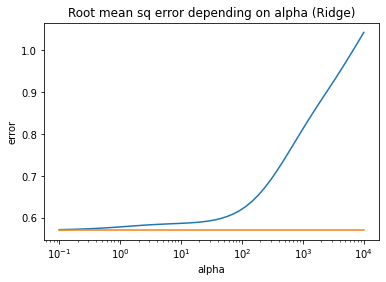

In [623]:
ax = plt.gca()

ax.plot(alphas, log_errors_Ridge)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Ridge)')
plt.show()

In [624]:
print('the minimal log_errors_Ridge is', min(log_errors_Ridge), 'in position', log_errors_Ridge.index(min(log_errors_Ridge)))
print('alpha parameter for the minimal error is', alphas[log_errors_Ridge.index(min(log_errors_Ridge))])

the minimal log_errors_Ridge is 0.5715148101577531 in position 0
alpha parameter for the minimal error is 0.1


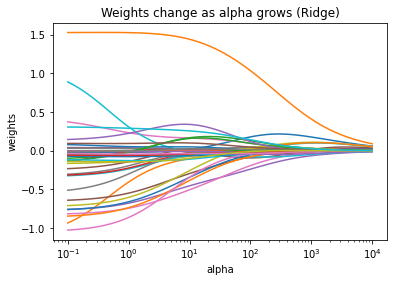

In [625]:
ax = plt.gca()

ax.plot(alphas, coefs_Ridge)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Ridge)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the ridge calculation below

### Lasso regression illustration: manual choice of alpha

In [626]:
baseline_error = np.sqrt(mean_squared_error(y_test, y_pred))
# it's a mean squared error from previous model, from Linear Regression

In [627]:
n_alphas = 50
alphas = np.logspace(-5, 1, n_alphas)

lasso = Lasso()
p1 = preprocessor1.fit(X_train)
X1 = p1.transform(X_train)
X2 = p1.transform(X_test)

coefs_Lasso = []
log_errors_Lasso = []
for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X1, y_train['LogGHGEmissions'])
    coefs_Lasso.append(lasso.coef_)
#     log_errors_Lasso.append(np.mean((lasso.predict(X2) - y_test['LogGHGEmissions']) ** 2).values[0])
    log_errors_Lasso.append(np.sqrt(np.mean((lasso.predict(X2) - y_test['LogGHGEmissions']) ** 2)))
#     it's the way to calculate mean squared error

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 133.7728671577838, tolerance: 0.1934366581871928
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 131.45962038789287, tolerance: 0.1934366581871928
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 128.4330654965573, tolerance: 0.1934366581871928
  model = cd_fast.enet_coordinate_descent(
C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: C

Sometimes we see that the curve (Lasso error) goes below the baseline (non regularized linear regression) before rising again.  Sometimes it doesn't go below: the two error lines go along, then Lasso Error rises high. 
It depends on individuals selected in train-test split: you can get the same behavior every time, if you define a random state.

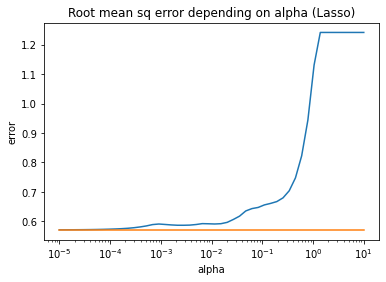

In [628]:
ax = plt.gca()

ax.plot(alphas, log_errors_Lasso)
ax.plot([alphas[0], alphas[-1]], [baseline_error, baseline_error])
ax.set_xscale('log')
ax.set(xlabel='alpha', ylabel='error', title='Root mean sq error depending on alpha (Lasso)')
plt.show()

In [629]:
print('the minimal log_errors_Lasso is', min(log_errors_Lasso), 'in position', log_errors_Lasso.index(min(log_errors_Lasso)))
print('alpha parameter for the minimal error is', alphas[log_errors_Lasso.index(min(log_errors_Lasso))])

the minimal log_errors_Lasso is 0.571351483118022 in position 0
alpha parameter for the minimal error is 1e-05


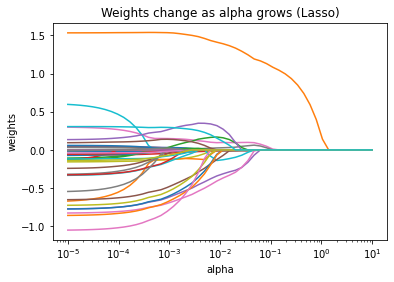

In [630]:
ax = plt.gca()

ax.plot(alphas, coefs_Lasso)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Weights change as alpha grows (Lasso)')
plt.axis('tight')
plt.show()

# if raises the error about wrong shape of "coefs", add coef_[0] to the lasso calculation below

### Ridge regression with cross-validation

In [631]:
param_test = {'alpha': np.logspace(0, 3, 10)}

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Ridge(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_ridge.py:555: UserWarning: "sag" solver requires many iterations to fit an intercept with sparse inputs. Either set the solver to "auto" or "sparse_cg", or set a low "tol" and a high "max_iter" (especially if inputs are not standardized).

'sag' solver was removed from the parameters grid.

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite: 

I have just kept only 'auto' solver.

In [632]:
# tygdyk
model[1].best_params_

{'alpha': 1.0}

In [633]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Ridge'
optimal_params.append(['Ridge', param_stock])

In [634]:
y_pred = model.predict(X_test)

log_errors.append(['Ridge', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [635]:
log_errors.append(['Ridge', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [636]:
errors.append(['Ridge', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Lasso regression with cross-validation

In [637]:
param_test = {'alpha': np.logspace(-3, 3, 7),
#               'precompute': [False, True],  # default parameter False is better for all the test I did
             'selection': ['random', 'cyclic']}


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=Lasso(tol=0.001, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

In [638]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'selection': 'cyclic'}

In [639]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Lasso'
optimal_params.append(['Lasso', param_stock])

In [640]:
y_pred = model.predict(X_test)

log_errors.append(['Lasso', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [641]:
log_errors.append(['Lasso', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [642]:
errors.append(['Lasso', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Elastic Net regression with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [643]:
param_test = {'alpha': np.logspace(-3, 3, 7),
             'l1_ratio': np.linspace(0.1, 0.9, 9),
#              'selection': ['random', 'cyclic']
             }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=ElasticNet(max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

for each of RMSE, MAE and R2 score

In [644]:
# tygdyk
model[1].best_params_

{'alpha': 0.001, 'l1_ratio': 0.9}

In [645]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Elastic Net'
optimal_params.append(['Elastic Net', param_stock])

In [646]:
y_pred = model.predict(X_test)

log_errors.append(['ElasticNet', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [647]:
log_errors.append(['ElasticNet', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [648]:
errors.append(['ElasticNet', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Random Forest Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [649]:
param_test = {'n_estimators': [50, 100, 200, 400], # of 50,100,200,400 best value is 200
#              'criterion': ['mse', 'mae'],  # default value is mse
             'max_depth': [4, 6, 9, None], 
#              'min_samples_split': [2, 4],  # default value 2 is the best
#              'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#              'min_weight_fraction_leaffloat': [0], 
#              'max_features': ['auto', 'sqrt', 'log'], # default value 'auto' is the best, = n_features
#              'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
#              'min_impurity_decrease'[0], 
#              'verbose': [0],
#              'ccp_alpha': [0],  # should be non-negative
#              'max_samples': [None]  #if None, draw X.shape[0] samples
             }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=RandomForestRegressor(), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:880: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:918: UserWarning: One or more of the test scores are non-finite:

In [650]:
# tygdyk
model[1].best_params_

{'max_depth': None, 'n_estimators': 400}

In [651]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Random Forest', param_stock])

In [652]:
y_pred = model.predict(X_test)

log_errors.append(['Random_Forest', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [653]:
log_errors.append(['Random_Forest', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [654]:
errors.append(['Random_Forest', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### Gradient Boosting Regressor with cross-validation

In [655]:
param_test = {'loss': ['ls', 'lad', 'huber', 'quantile'], # huber is the best
#               'learning_rate': [0.2, 0.1, 0.05], # default value 0.1 is best of 0.2, 0.1, 0.05
              'n_estimators': [100, 200, 400, 600], # of best value is 400, sometimes 200
              'max_depth': [4, 6, 9, None], # default value None is the best, sometimes 4
#               'subsample': [1.0, 0.9],
#               'min_samples_split': [2, 5, 10],  # default value 2 is the best
#               'min_samples_leaf': [1, 2, 3], # default value 1 is the best
#               'min_weight_fraction_leaf': [0, 0.1], # default value 0 is the best
#               'max_features': ['auto', 'sqrt'], # default value 'auto' is the best, 'log' rises an error, model not converged
#               'max_leaf_nodes': [None],  # None means unlimited number of leaf nodes
              'min_impurity_decrease': [0.001, 0.01, 0.1, 1],  # best param varies from one click to another
              }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=GradientBoostingRegressor(n_iter_no_change=5, tol = 0.1), 
                          param_grid=param_test, 
                          cv=3, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

In [656]:
# tygdyk
model[1].best_params_

{'loss': 'ls',
 'max_depth': 4,
 'min_impurity_decrease': 0.01,
 'n_estimators': 400}

In [657]:
param_stock = model[1].best_params_
# param_stock['name'] = 'Random Forest'
optimal_params.append(['Gradient Boosting Regressor', param_stock])

In [658]:
y_pred = model.predict(X_test)

log_errors.append(['Gradient_Boosting', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [659]:
log_errors.append(['Gradient_Boosting', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [660]:
errors.append(['Gradient_Boosting', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

###  XGB Regressor with cross-validation, Learning API

In [661]:
prepr_fitted = preprocessor1.fit(X_train)
X1 = prepr_fitted.transform(X_train)
X2 = prepr_fitted.transform(X_test)

dtrain = xgb.DMatrix(X1, label=y_train['LogGHGEmissions'])
dtest = xgb.DMatrix(X2, label=y_test['LogGHGEmissions'])

In [662]:
# guide for parameters tuning: https://blog.cambridgespark.com/hyperparameter-tuning-in-xgboost-4ff9100a3b2f
# notice the importance of the seed

params = {
    # Parameters that we are going to tune.
    'max_depth':6,
    'min_child_weight': 1,
    'eta':.3,
    'subsample': 1,
    'colsample_bytree': 1,
    # Other parameters
    'objective':'reg:squarederror',
    'eval_metric': ['rmse', 'mae']
}
num_boost_round = 999

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/objective/regression_obj.cu:171: reg:linear is now deprecated in favor of reg:squarederror.

In [663]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:2.60708	Test-mae:2.42061
[1]	Test-rmse:1.88333	Test-mae:1.70697
[2]	Test-rmse:1.40944	Test-mae:1.22652
[3]	Test-rmse:1.09453	Test-mae:0.91432
[4]	Test-rmse:0.88294	Test-mae:0.72525
[5]	Test-rmse:0.76329	Test-mae:0.62359
[6]	Test-rmse:0.69046	Test-mae:0.56876
[7]	Test-rmse:0.64450	Test-mae:0.52945
[8]	Test-rmse:0.62118	Test-mae:0.51107
[9]	Test-rmse:0.60771	Test-mae:0.49958
[10]	Test-rmse:0.60362	Test-mae:0.49455
[11]	Test-rmse:0.59659	Test-mae:0.48795
[12]	Test-rmse:0.59552	Test-mae:0.48721
[13]	Test-rmse:0.59006	Test-mae:0.48182
[14]	Test-rmse:0.59184	Test-mae:0.48531
[15]	Test-rmse:0.59245	Test-mae:0.48462
[16]	Test-rmse:0.58864	Test-mae:0.48222
[17]	Test-rmse:0.59205	Test-mae:0.48292
[18]	Test-rmse:0.58741	Test-mae:0.47734
[19]	Test-rmse:0.58596	Test-mae:0.47633
[20]	Test-rmse:0.59145	Test-mae:0.47894
[21]	Test-rmse:0.59145	Test-mae:0.47897
[22]	Test-rmse:0.59098	Test-mae:0.47785
[23]	Test-rmse:0.59101	Test-mae:0.47605
[24]	Test-rmse:0.59714	Test-mae:0.48074
[25]	Test-

In [664]:
print("Best MAE: {:.2f} with {} rounds".format(
                 model.best_score,
                 model.best_iteration+1))

Best MAE: 0.48 with 24 rounds


In [665]:
cv_results = xgb.cv(params, 
                    dtrain, 
                    num_boost_round=num_boost_round, 
                    seed=42, 
                    nfold=5, 
                    metrics={'rmse', 'mae'},  # 'r2' or 'r2score' doesn't exist
                    early_stopping_rounds=10)

In [666]:
cv_results['test-mae-mean'].min()

0.46660880000000005

In [667]:
gridsearch_params = [
    (max_depth, min_child_weight)
    for max_depth in (2,3,6)
    for min_child_weight in np.logspace(-8, 0, 3) #in range(5,8)
]

In [668]:
# Define initial best params and MAE
min_mae = float("Inf")
min_rmse = float("Inf")
# best_params = None

for max_depth, min_child_weight in gridsearch_params:
#     print("CV with max_depth={}, min_child_weight={}".format(
#                              max_depth,
#                              min_child_weight))
    # Update our parameters
    params['max_depth'] = max_depth
    params['min_child_weight'] = min_child_weight
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best MAE
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (max_depth,min_child_weight)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}, RMSE: {}".format(best_params[0], best_params[1], min_mae, min_rmse))

params['max_depth'] = best_params[0]
params['min_child_weight'] = best_params[1]

Best params: 3, 1e-08, MAE: 0.46385060000000006, RMSE: 0.5576916000000001


In [669]:
gridsearch_params = [
    (subsample, colsample)
    for subsample in [i/10. for i in range(6,11,2)]
    for colsample in [i/10. for i in range(6,11,2)]
]

In [670]:
min_mae = float("Inf")
min_rmse = float("Inf")
best_params = None

# Start by the largest values and go down to the smallest
for subsample, colsample in reversed(gridsearch_params):
#     print("CV with subsample={}, colsample={}".format(
#                              subsample,
#                              colsample))

    # Update parameters
    params['subsample'] = subsample
    params['colsample_bytree'] = colsample
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'rmse','mae'},
        early_stopping_rounds=10
    )
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-rmse-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (subsample,colsample)
    if mean_rmse < min_rmse:
        min_rmse = mean_rmse
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

params['subsample'] = best_params[0]
params['colsample_bytree'] = best_params[1]

Best params: 0.8, 0.8, MAE: 0.4556509999999999


In [671]:
%time
min_mae = float("Inf")
best_params = None
for eta in [.3, .2, .1, .05, .01, .005]:
#     print("CV with eta={}".format(eta))
    
    # Update parameters
    params['eta'] = eta
    # Run and time CV
    %time cv_results = xgb.cv(params,dtrain,num_boost_round=num_boost_round,seed=42,nfold=5,metrics=['rmse','mae'],early_stopping_rounds=10)
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    mean_rmse = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
#     print("\tMAE {} for {} rounds\n".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = eta
    if mean_mae < min_mae:
        min_mae = mean_mae
print("Best params: {}, MAE: {}, RMSE: {}".format(best_params, min_mae, min_rmse))

params['eta'] = best_params

Wall time: 0 ns
Wall time: 435 ms
Wall time: 458 ms
Wall time: 1.08 s
Wall time: 1.53 s
Wall time: 4.71 s
Wall time: 4.89 s
Best params: 0.1, MAE: 0.452822, RMSE: 0.556769


In [672]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10)

[0]	Test-rmse:3.30789	Test-mae:3.10133
[1]	Test-rmse:2.98727	Test-mae:2.78971
[2]	Test-rmse:2.69958	Test-mae:2.50872
[3]	Test-rmse:2.44427	Test-mae:2.25881
[4]	Test-rmse:2.21610	Test-mae:2.03336
[5]	Test-rmse:2.01257	Test-mae:1.83074
[6]	Test-rmse:1.83048	Test-mae:1.64790
[7]	Test-rmse:1.66663	Test-mae:1.47873
[8]	Test-rmse:1.51997	Test-mae:1.32859
[9]	Test-rmse:1.39638	Test-mae:1.20598
[10]	Test-rmse:1.28204	Test-mae:1.09186
[11]	Test-rmse:1.18250	Test-mae:0.99551
[12]	Test-rmse:1.09910	Test-mae:0.92195
[13]	Test-rmse:1.02075	Test-mae:0.84927
[14]	Test-rmse:0.95780	Test-mae:0.78985
[15]	Test-rmse:0.90262	Test-mae:0.74129
[16]	Test-rmse:0.85303	Test-mae:0.69829
[17]	Test-rmse:0.81239	Test-mae:0.66714
[18]	Test-rmse:0.77690	Test-mae:0.63937
[19]	Test-rmse:0.74790	Test-mae:0.61762
[20]	Test-rmse:0.72094	Test-mae:0.60054
[21]	Test-rmse:0.69729	Test-mae:0.58407
[22]	Test-rmse:0.67914	Test-mae:0.57062
[23]	Test-rmse:0.66314	Test-mae:0.55983
[24]	Test-rmse:0.64935	Test-mae:0.54995
[25]	Test-

In [673]:
print("Best MAE: {:.2f} in {} rounds".format(model.best_score, model.best_iteration+1))

Best MAE: 0.47 in 82 rounds


In [674]:
num_boost_round = model.best_iteration + 1
best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")])

[0]	Test-rmse:3.30789	Test-mae:3.10133
[1]	Test-rmse:2.98727	Test-mae:2.78971
[2]	Test-rmse:2.69958	Test-mae:2.50872
[3]	Test-rmse:2.44427	Test-mae:2.25881
[4]	Test-rmse:2.21610	Test-mae:2.03336
[5]	Test-rmse:2.01257	Test-mae:1.83074
[6]	Test-rmse:1.83048	Test-mae:1.64790
[7]	Test-rmse:1.66663	Test-mae:1.47873
[8]	Test-rmse:1.51997	Test-mae:1.32859
[9]	Test-rmse:1.39638	Test-mae:1.20598
[10]	Test-rmse:1.28204	Test-mae:1.09186
[11]	Test-rmse:1.18250	Test-mae:0.99551
[12]	Test-rmse:1.09910	Test-mae:0.92195
[13]	Test-rmse:1.02075	Test-mae:0.84927
[14]	Test-rmse:0.95780	Test-mae:0.78985
[15]	Test-rmse:0.90262	Test-mae:0.74129
[16]	Test-rmse:0.85303	Test-mae:0.69829
[17]	Test-rmse:0.81239	Test-mae:0.66714
[18]	Test-rmse:0.77690	Test-mae:0.63937
[19]	Test-rmse:0.74790	Test-mae:0.61762
[20]	Test-rmse:0.72094	Test-mae:0.60054
[21]	Test-rmse:0.69729	Test-mae:0.58407
[22]	Test-rmse:0.67914	Test-mae:0.57062
[23]	Test-rmse:0.66314	Test-mae:0.55983
[24]	Test-rmse:0.64935	Test-mae:0.54995
[25]	Test-

'num_boost_round': 200 in params raises an error:

WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "num_boost_round" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.

In [675]:
y_pred = best_model.predict(dtest)
mean_absolute_error(y_pred, y_test)
np.sqrt(mean_squared_error(y_test, y_pred))

0.5633017428681037

In [676]:
y_pred = best_model.predict(dtest)

In [677]:
log_errors.append(['XGB_LearningAPI', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               9.999])

As XGBoost doesn't have R2 score in metrics in cross-validation, I calculate a train r2 score without cross-validation. 
Minimal RMSE and MAE can be found from cv_results dataframe, but the model has been updated since that: not only the parameters are optimized, but the number of iterations as well.

In [678]:
y_train_pred = best_model.predict(dtrain)

log_errors.append(['XGB_LearningAPI', 'from_train', 'without_score',
               round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 3),
               round(mean_absolute_error(y_train, y_train_pred), 3),
               round(r2_score(y_train, y_train_pred), 3),
#                model.score(X_train, y_train),
               9.999])

In [679]:
errors.append(['XGB_LearningAPI', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

###  XGB Regressor with cross-validation, SKLearn API (wrapper)

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [680]:
# question: is alpha_reg the same thing that alpha? and lambda_reg the same thing that lambda?

# params explained: https://towardsdatascience.com/xgboost-fine-tune-and-optimize-your-model-23d996fab663
# full list of params https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn
# parameters: general ones, and divided by subcategory: https://xgboost.readthedocs.io/en/latest/parameter.html

param_test = {
#            'max_depth': [3, 6, 10], # by default 6, and 6 have been shown the best
           'learning_rate': [0.01], # by default 0.3, [0.01, 0.3] 0.01 is better but much slower
           'n_estimators': [100, 500, 1000], # by default 100
#            'colsample_bytree': [0.3, 0.7], # default value 1 is the best
           'alpha': [0, 0.001, 0.01, 0.1],# by default 0, best shown 0.001
           'lambda': [1, 3, 5]  # default is 1, best shown 3 from 0.1,1,3
            }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=XGBRegressor(objective='reg:squarederror', base_score=y_train['LogGHGEmissions'].median()), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

In [681]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0.001, 'lambda': 3, 'learning_rate': 0.01, 'n_estimators': 1000}

In [682]:
param_stock = model[1].best_params_
# param_stock['name'] = 'XGBRegressor'
optimal_params.append(['XGBRegressor', param_stock])

In [683]:
param_stock

{'alpha': 0.001, 'lambda': 3, 'learning_rate': 0.01, 'n_estimators': 1000}

In [684]:
# model[1].cv_results_ extremely long dictionary

In [685]:
y_pred = model.predict(X_test)

log_errors.append(['XGBRegressor', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [686]:
log_errors.append(['XGBRegressor', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [687]:
errors.append(['XGBRegressor', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### SGD Regressor with cross-validation (Stochastic Gradient Descent)

The gradient of the loss is estimated each sample at a time and the model is updated along the way with a decreasing strength schedule (aka learning rate).

The regularizer is a penalty added to the loss function that shrinks model parameters towards the zero vector using either the squared euclidean norm L2 or the absolute norm L1 or a combination of both (Elastic Net). If the parameter update crosses the 0.0 value because of the regularizer, the update is truncated to 0.0 to allow for learning sparse models and achieve online feature selection.

This implementation works with data represented as dense numpy arrays of floating point values for the features.

In [688]:
param_test = {
    'alpha': np.logspace(-3, 3, 7),
    'loss': ['squared_loss', 'huber'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
    'penalty': ['l2', 'l1', 'elasticnet'],
    'l1_ratio': [0.15, 0.5],
    'learning_rate': ['constant', 'invscaling', 'adaptive'], # default invscaling
    }

pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SGDRegressor(tol=0.001, max_iter=10_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1220: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

In [689]:
# tygdyk
model[1].best_params_
# colsample_by_tree and n_estimators are maximal, max depth is by default 6
# {'colsample_bytree': 0.7,
#  'learning_rate': 0.01,
#  'max_depth': 6,
#  'n_estimators': 1000}

{'alpha': 0.01,
 'l1_ratio': 0.5,
 'learning_rate': 'adaptive',
 'loss': 'squared_loss',
 'penalty': 'elasticnet'}

In [690]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SGDegressor'
optimal_params.append(['SGDegressor', param_stock])

In [691]:
y_pred = model.predict(X_test)

log_errors.append(['SGDRegressor', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [692]:
log_errors.append(['SGDRegressor', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [693]:
errors.append(['SGDRegressor', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

### SV Regressor with cross-validation

It helps to get more accurate estimation  of error metrics. Note the values of the metrics: they differ from those with only one train/test.

In [694]:
param_test = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # exist also 'epsilon_insensitive', as in SVR and 'squared_epsilon_insensitive'
#     kernel 'precomputed' raises an error: the precomputed kernel matrix must be used
    'C': [1, 10, 100] # default is 1, best is 5 from 0.2, 1, 5
    }


pipe_grid = make_pipeline(preprocessor1, 
                      GridSearchCV(
                          estimator=SVR(tol=0.001, max_iter=1_000_000), 
                          param_grid=param_test, 
                          cv=5, 
                          scoring=('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'), 
#                           return_train_score = True, 
                          refit='neg_mean_squared_error', 
                          n_jobs = -1))

model = pipe_grid.fit(X_train, y_train['LogGHGEmissions'])

C:\Users\Veronika\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

In [695]:
# tygdyk
model[1].best_params_

{'C': 1, 'kernel': 'linear'}

In [696]:
param_stock = model[1].best_params_
# param_stock['name'] = 'SVR'
optimal_params.append(['SVR', param_stock])

In [697]:
y_pred = model.predict(X_test)

log_errors.append(['SVR', 'from_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
               round(mean_absolute_error(y_test, y_pred), 3),
               round(r2_score(y_test, y_pred), 3),
#                model.score(X_train, y_train),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [698]:
log_errors.append(['SVR', 'from_train', 'without_score',
               round(np.sqrt(-model[1].cv_results_['mean_test_neg_mean_squared_error'][model[1].best_index_]), 3),
               round(-model[1].cv_results_['mean_test_neg_mean_absolute_error'][model[1].best_index_], 3),
               round(model[1].cv_results_['mean_test_r2'][model[1].best_index_], 3),
#                round(model[1].cv_results_['mean_train_r2'][model[1].best_index_], 3),
               model[1].cv_results_['mean_fit_time'][model[1].best_index_]])

In [699]:
errors.append(['SVR', 'from_log_test', 'without_score',
               round(np.sqrt(mean_squared_error(y_test_exp, np.exp(y_pred))), 3),
               round(mean_absolute_error(y_test_exp, np.exp(y_pred)), 3),
               round(r2_score(y_test_exp, np.exp(y_pred)), 3), 
#                round(r2_score(y_train, np.exp(y_pred_train))), 3), 
               fit_time - start])

# Model performance comparison (synthesis table)

In [700]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [701]:
df_results = pd.DataFrame(errors,columns=['Model', 'Source', 'Variables', 'RMSE', 'MAE', 'R2Score', 'Fit time'])

In [702]:
# df_results = df_results_full.drop(['MAE', 'R2Score', 'Fit time'], axis=1)

In [703]:
log_results = pd.DataFrame(log_errors,columns=['Model', 'Source', 'Variables', 'RMSE', 'MAE', 'R2Score', 'Fit time'])

In [704]:
# display(df_results.sort_values(by='RMSE').head(10))
display(df_results[df_results.Source != 'from_train'].sort_values(by='RMSE').head())
display(df_results[df_results.Source == 'from_test'].sort_values(by='RMSE').head())
display(df_results[df_results.Source == 'from_log_test'].sort_values(by='RMSE').head())

,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
14,XGB_LearningAPI,from_test,with_score,60.167,34.634,0.794,9.999
12,Gradient_Boosting,from_test,with_score,63.913,35.821,0.767,6.111
49,XGBRegressor,from_test,without_score,65.838,38.570,0.753,5.990
16,XGBRegressor,from_test,with_score,66.048,37.331,0.751,0.939
30,XGBRegressor,from_log_test,with_score,72.033,36.032,0.704,0.014


,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
14,XGB_LearningAPI,from_test,with_score,60.167,34.634,0.794,9.999
12,Gradient_Boosting,from_test,with_score,63.913,35.821,0.767,6.111
49,XGBRegressor,from_test,without_score,65.838,38.570,0.753,5.990
16,XGBRegressor,from_test,with_score,66.048,37.331,0.751,0.939
10,Random_Forest,from_test,with_score,74.046,40.291,0.687,0.846


,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
30,XGBRegressor,from_log_test,with_score,72.033,36.032,0.704,0.014
27,Random_Forest,from_log_test,with_score,74.122,36.978,0.687,3.822
63,XGBRegressor,from_log_test,without_score,75.098,39.586,0.678,0.015
29,XGB_LearningAPI,from_log_test,with_score,75.204,36.719,0.677,0.014
60,Random_Forest,from_log_test,without_score,75.680,39.711,0.673,0.015


### And best model is:
#### With Energy Star score:
XGBRegressor (SKLearnAPI)with Log Transform! (random_state of train_test_split=2)
XGBRegressor (SKLearnAPI)with Log Transform! (random_state of train_test_split=3)
XGBRegressor (SKLearnAPI)WITHOUT SCORE! (random_state of train_test_split=4)
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=7) 

Second place: 
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=2)
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=3)
XGBRegressor (SKLearnAPI)with Log Transform WITHOUT SCORE! (random_state of train_test_split=4)
XGBRegressor (SKLearnAPI)WITHOUT SCORE! (random_state of train_test_split=7)

#### Without Energy Star score:
XGBRegressor LearningAPI with Log Transform! (random_state of train_test_split=2)
XGBRegressor LearningAPI with Log Transform! (random_state of train_test_split=3)
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=4)
XGBRegressor (SKLearnAPI)! (random_state of train_test_split=7) 

Second place: 
Gradient_Boosting! (random_state of train_test_split=2)
Gradient_Boosting! (random_state of train_test_split=3)
XGBRegressor (SKLearnAPI)with Log Transform! (random_state of train_test_split=4)
Gradient_Boosting! (random_state of train_test_split=7)

In [705]:
without_score = df_results[df_results.Variables == 'without_score']

In [706]:
# display(without_score.sort_values(by='RMSE').head(15))
display(without_score[without_score.Source != 'from_train'].sort_values(by='RMSE').head())
display(without_score[without_score.Source == 'from_test'].sort_values(by='RMSE').head())
display(without_score[without_score.Source == 'from_log_test'].sort_values(by='RMSE').head())

,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
49,XGBRegressor,from_test,without_score,65.838,38.570,0.753,5.990
47,XGB_LearningAPI,from_test,without_score,74.671,42.351,0.682,9.999
63,XGBRegressor,from_log_test,without_score,75.098,39.586,0.678,0.015
60,Random_Forest,from_log_test,without_score,75.680,39.711,0.673,0.015
43,Random_Forest,from_test,without_score,78.433,42.728,0.649,3.702


,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
49,XGBRegressor,from_test,without_score,65.838,38.570,0.753,5.990
47,XGB_LearningAPI,from_test,without_score,74.671,42.351,0.682,9.999
43,Random_Forest,from_test,without_score,78.433,42.728,0.649,3.702
53,SVR,from_test,without_score,87.875,49.417,0.560,0.263
51,SGDRegressor,from_test,without_score,88.798,56.824,0.550,0.018


,Model,Source,Variables,RMSE,MAE,R2Score,Fit time
63,XGBRegressor,from_log_test,without_score,75.098,39.586,0.678,0.015
60,Random_Forest,from_log_test,without_score,75.680,39.711,0.673,0.015
62,XGB_LearningAPI,from_log_test,without_score,78.651,40.469,0.647,0.015
64,SGDRegressor,from_log_test,without_score,81.139,44.078,0.624,0.015
58,Lasso,from_log_test,without_score,81.949,43.351,0.617,0.015


## Performance with or without LogTransformation of Targets

In [707]:
savepath = 'C:\\Users\\Veronika\\Dropbox\\OpenClassrooms\\SupP4CO2RandState2\\'

With EnergyStar score

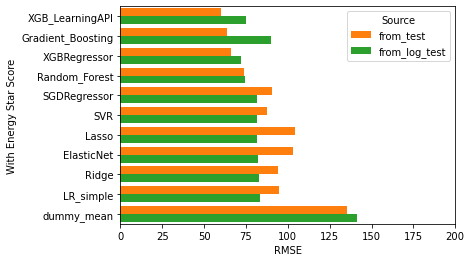

In [708]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_test', 'from_log_test'],
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source != 'from_train')].sort_values('RMSE'), 
                 palette = ['tab:orange', 'tab:green'], saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
plt.savefig(savepath+'001', bbox_inches='tight')

Without EnergyStar score

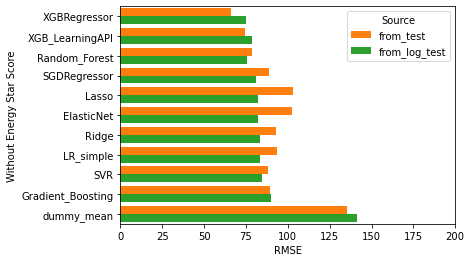

In [709]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_test', 'from_log_test'],
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source != 'from_train')].sort_values('RMSE'), 
                 palette = ['tab:orange', 'tab:green'], saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
plt.savefig(savepath+'002', bbox_inches='tight')

Which models are overfitted?

If we see a big difference, that the train error is much lower than the test error, it means model is overfitted.

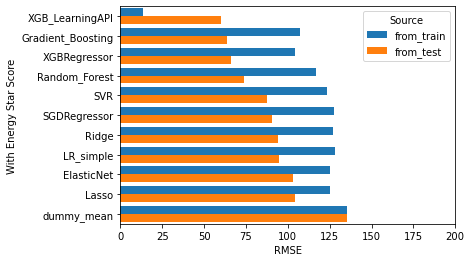

In [710]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_train', 'from_test'],
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source != 'from_log_test')].sort_values('RMSE'), 
                 palette = ['tab:blue', 'tab:orange'], saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
plt.savefig(savepath+'003', bbox_inches='tight')

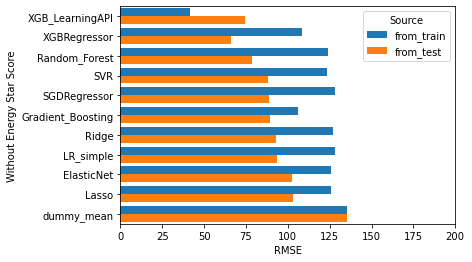

In [711]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_train', 'from_test'],
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source != 'from_log_test')].sort_values('RMSE'), 
                 palette = ['tab:blue', 'tab:orange'], saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
plt.savefig(savepath+'004', bbox_inches='tight')

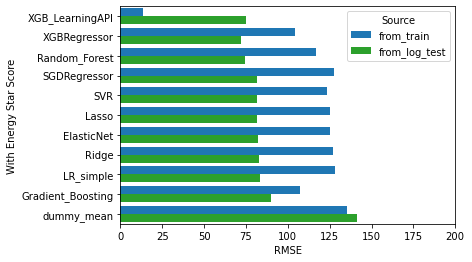

In [712]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_train', 'from_log_test'],
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source != 'from_test')].sort_values('RMSE'), 
                 palette = ['tab:blue', 'tab:green'], saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
plt.savefig(savepath+'005', bbox_inches='tight')

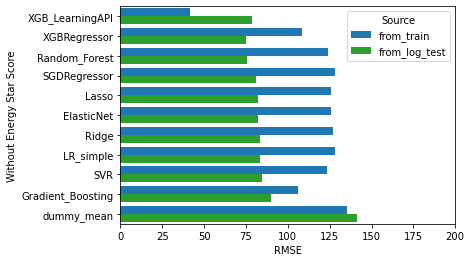

In [713]:
ax = sns.barplot(x='RMSE', y='Model', hue='Source', hue_order=['from_train', 'from_log_test'],
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source != 'from_test')].sort_values('RMSE'), 
                 palette = ['tab:blue', 'tab:green'], saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
plt.savefig(savepath+'006', bbox_inches='tight')

With logarithm transform RMS errors are not always lower. Let's see what's the best model 

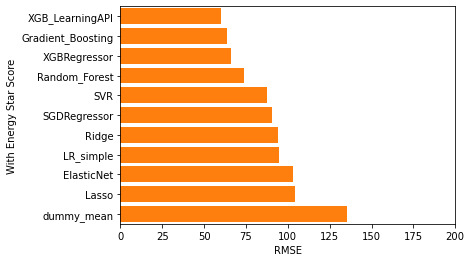

In [714]:
ax = sns.barplot(x='RMSE', y='Model',
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source == 'from_test')].sort_values('RMSE'), 
                 color='tab:orange', saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
plt.savefig(savepath+'007', bbox_inches='tight')

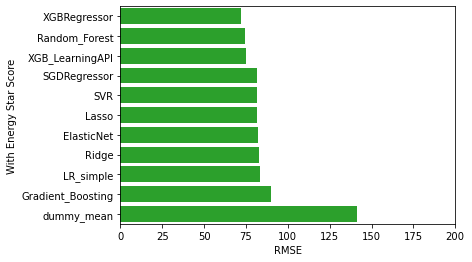

In [715]:
ax = sns.barplot(x='RMSE', y='Model',
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source == 'from_log_test')].sort_values('RMSE'), 
                 color='tab:green', saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('With Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('With Energy Star Score')
plt.savefig(savepath+'008', bbox_inches='tight')

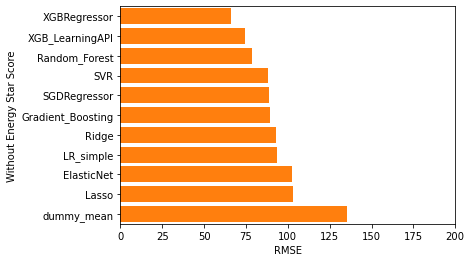

In [716]:
ax = sns.barplot(x='RMSE', y='Model',
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source == 'from_test')].sort_values('RMSE'), 
                 color='tab:orange', saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
plt.savefig(savepath+'009', bbox_inches='tight')

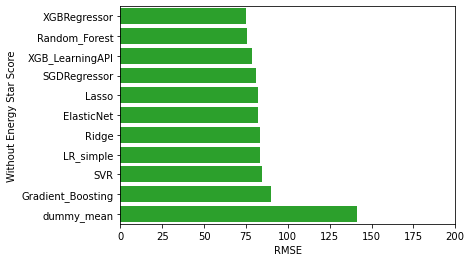

In [717]:
ax = sns.barplot(x='RMSE', y='Model',
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source == 'from_log_test')].sort_values('RMSE'), 
                 color='tab:green', saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Without Energy Star Score')
# ax.set_ylabel(None)
# ax.set_title('Without Energy Star Score')
plt.savefig(savepath+'010', bbox_inches='tight')

## Performance with or without EnergyStarScore

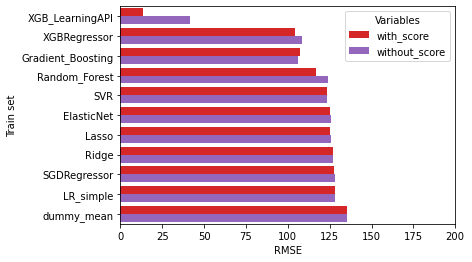

In [718]:
ax = sns.barplot(x='RMSE', y='Model', hue='Variables', hue_order=['with_score', 'without_score'],
                 data=df_results[df_results.Source == 'from_train'].sort_values('RMSE'),
                 palette = ['tab:red', 'tab:purple'], saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Train set')
# ax.set_ylabel(None)
# ax.set_title('Train set')
plt.savefig(savepath+'011', bbox_inches='tight')

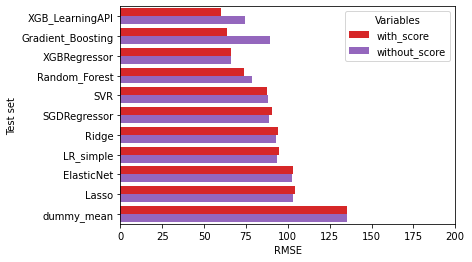

In [719]:
ax = sns.barplot(x='RMSE', y='Model', hue='Variables', hue_order=['with_score', 'without_score'],
                 data=df_results[df_results.Source == 'from_test'].sort_values('RMSE'),
                 palette = ['tab:red', 'tab:purple'], saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Test set')
# ax.set_ylabel(None)
# ax.set_title('Test set')
plt.savefig(savepath+'012', bbox_inches='tight')

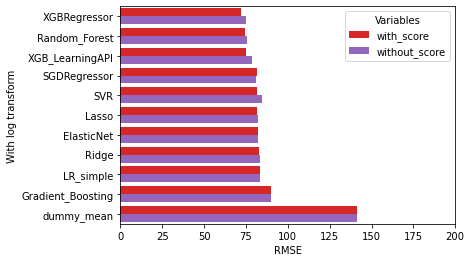

In [720]:
ax = sns.barplot(x='RMSE', y='Model', hue='Variables', hue_order=['with_score', 'without_score'],
                 data=df_results[df_results.Source == 'from_log_test'].sort_values('RMSE'),
                 palette = ['tab:red', 'tab:purple'], saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('With log transform')
# ax.set_ylabel(None)
# ax.set_title('With log transform')
plt.savefig(savepath+'013', bbox_inches='tight')

With EnergyStarScore errors are lower. Let's see what's the best model 

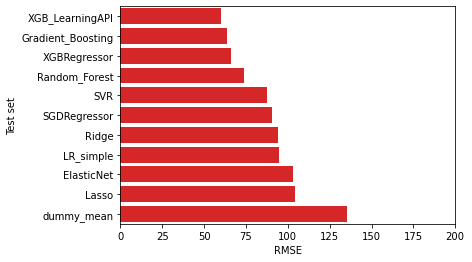

In [721]:
ax = sns.barplot(x='RMSE', y='Model',
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source == 'from_test')].sort_values('RMSE'), 
                 color='tab:red', saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Test set')
# ax.set_ylabel(None)
# ax.set_title('Test set')
plt.savefig(savepath+'014', bbox_inches='tight')

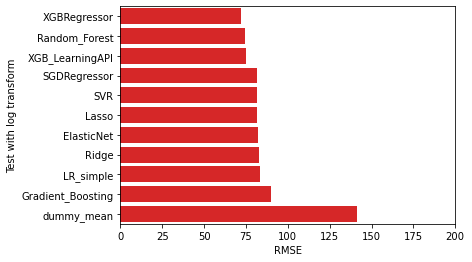

In [722]:
ax = sns.barplot(x='RMSE', y='Model',
data=df_results[(df_results.Variables == 'with_score') & (df_results.Source == 'from_log_test')].sort_values('RMSE'), 
                 color='tab:red', saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Test with log transform')
# ax.set_ylabel(None)
# ax.set_title('Test with log transform')
plt.savefig(savepath+'015', bbox_inches='tight')

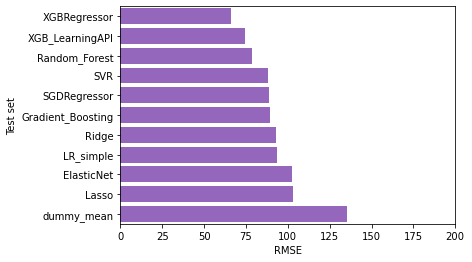

In [723]:
ax = sns.barplot(x='RMSE', y='Model',
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source == 'from_test')].sort_values('RMSE'), 
                 color='tab:purple', saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Test set')
# ax.set_ylabel(None)
# ax.set_title('Test set')
plt.savefig(savepath+'016', bbox_inches='tight')

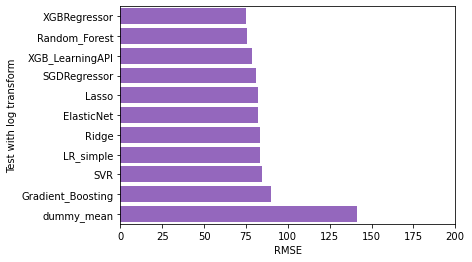

In [724]:
ax = sns.barplot(x='RMSE', y='Model',
data=df_results[(df_results.Variables == 'without_score') & (df_results.Source == 'from_log_test')].sort_values('RMSE'), 
                 color='tab:purple', saturation=1)
ax.set_xlim(0, 200)
ax.set_ylabel('Test with log transform')
# ax.set_ylabel(None)
# ax.set_title('Test with log transform')
plt.savefig(savepath+'017', bbox_inches='tight')

### Individual graphics for models

In [725]:
df_results['SourceVariables'] = df_results['Source'] + ', ' + df_results['Variables']

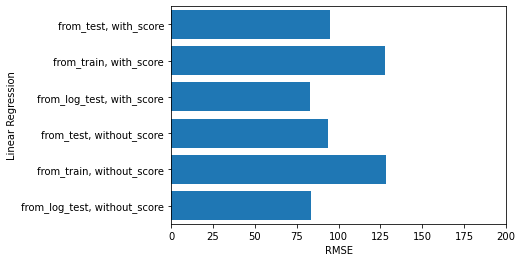

In [726]:
selection = df_results[df_results.Model == 'LR_simple']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Linear Regression')
ax.set_xlim(0, 200)
plt.savefig(savepath+'018', bbox_inches='tight')

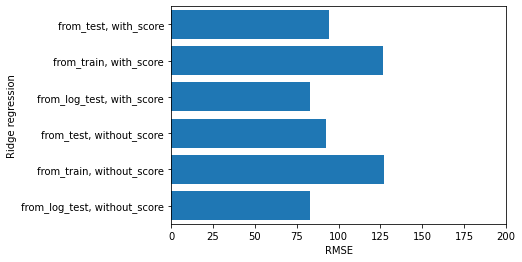

In [727]:
selection = df_results[df_results.Model == 'Ridge']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Ridge regression')
ax.set_xlim(0, 200)
plt.savefig(savepath+'019', bbox_inches='tight')

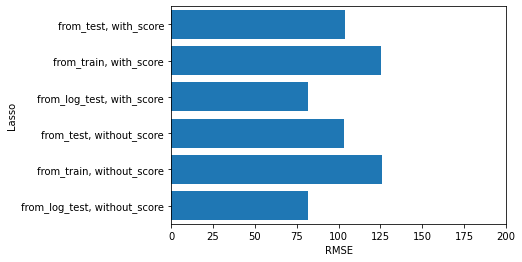

In [728]:
selection = df_results[df_results.Model == 'Lasso']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Lasso')
ax.set_xlim(0, 200)
plt.savefig(savepath+'020', bbox_inches='tight')

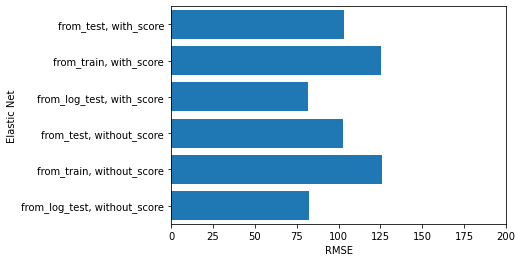

In [729]:
selection = df_results[df_results.Model == 'ElasticNet']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Elastic Net')
ax.set_xlim(0, 200)
plt.savefig(savepath+'021', bbox_inches='tight')

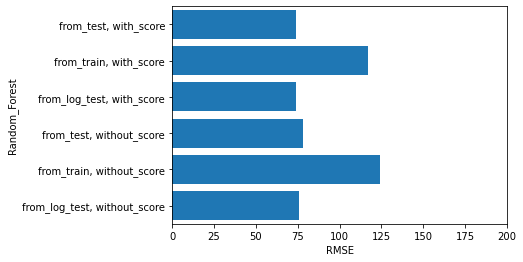

In [730]:
selection = df_results[df_results.Model == 'Random_Forest']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Random_Forest')
ax.set_xlim(0, 200)
plt.savefig(savepath+'022', bbox_inches='tight')

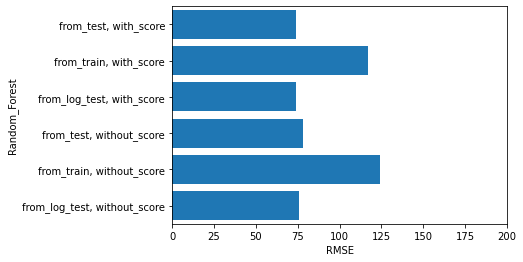

In [731]:
selection = df_results[df_results.Model == 'Random_Forest']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Random_Forest')
ax.set_xlim(0, 200)
plt.savefig(savepath+'023', bbox_inches='tight')

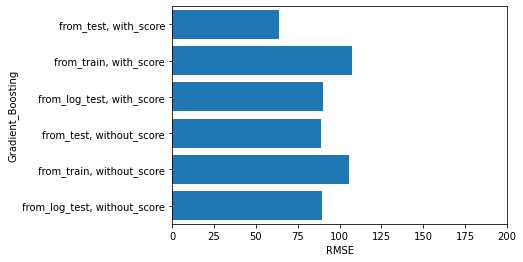

In [732]:
selection = df_results[df_results.Model == 'Gradient_Boosting']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('Gradient_Boosting')
ax.set_xlim(0, 200)
plt.savefig(savepath+'024', bbox_inches='tight')

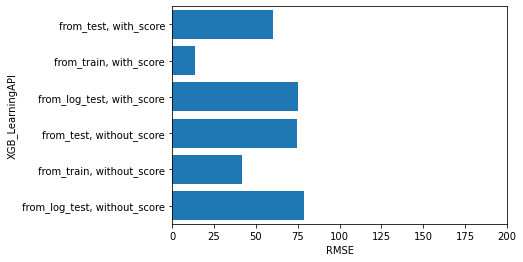

In [733]:
selection = df_results[df_results.Model == 'XGB_LearningAPI']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('XGB_LearningAPI')
ax.set_xlim(0, 200)
plt.savefig(savepath+'025', bbox_inches='tight')

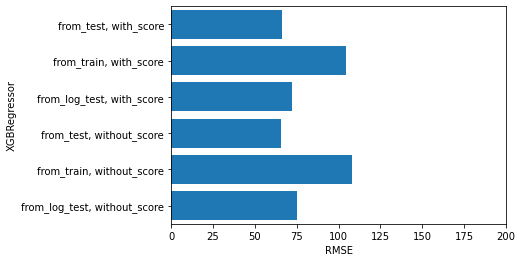

In [734]:
selection = df_results[df_results.Model == 'XGBRegressor']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('XGBRegressor')
ax.set_xlim(0, 200)
plt.savefig(savepath+'026', bbox_inches='tight')

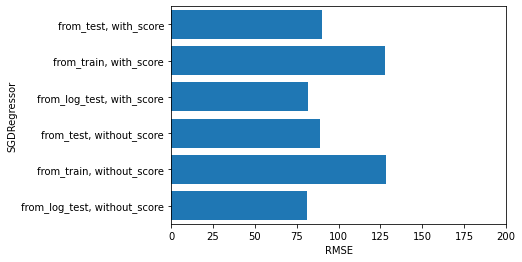

In [735]:
selection = df_results[df_results.Model == 'SGDRegressor']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('SGDRegressor')
ax.set_xlim(0, 200)
plt.savefig(savepath+'027', bbox_inches='tight')

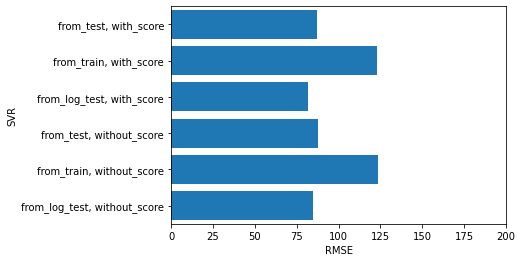

In [736]:
selection = df_results[df_results.Model == 'SVR']

ax = sns.barplot(x='RMSE', 
                 y='SourceVariables', 
                 data=selection,
                 color='tab:blue',
                saturation=1)
ax.set_ylabel('SVR')
ax.set_xlim(0, 200)
plt.savefig(savepath+'028', bbox_inches='tight')